# 배터리팩 이상 탐지 발표 노트북

## 배경
배터리팩 충·방전 시험은 수작업으로 진행되며 숙련 기술자 의존도가 높습니다.
불량 발생 시 원인 분석과 교체 판정에 경계성 판단이 요구되므로, 이 과정을 데이터 기반으로 보조하는 것이 목표입니다.

## 목표
- 학습 데이터 내부 검증으로 모델 설정과 이상 판정 기준을 자동으로 도출합니다.
- 평가는 최종 설정을 그대로 적용해 일반화 성능을 확인합니다.
- 이상 점수에 고장 단서를 더해 불필요한 경보를 줄입니다.

## 탐지 파이프라인

| 단계 | 방법 | 역할 |
|---|---|---|
| 특징 추출 | 슬라이딩 윈도우 + 행 단위 지표 | 셀 전압·온도 변화를 수치화 |
| 차원 축소 | PCA (분산 보존 기준 선택) | 노이즈 제거, 탐색 비용 감소 |
| 이상 점수 | One-Class SVM | 정상 데이터만으로 이상 여부 판별 |
| 기본 후처리 | 구간 병합·길이·강도 필터 | 짧은 잡음 제거, 안정적 경보 |
| 고장 인지 후처리 | 고장 단서 점수 반영 | 고장 유형별 보강/기각으로 오탐 감소 |

## 데이터셋 출처
- [KAMP 전자부품(배터리팩) 품질보증 AI 데이터셋](https://www.kamp-ai.kr/aidataDetail?AI_SEARCH=&page=2&DATASET_SEQ=58&DISPLAY_MODE_SEL=CARD&EQUIP_SEL=&GUBUN_SEL=C004027&FILE_TYPE_SEL=C005002&WDATE_SEL=)

## 진행 순서
1. 데이터 정리와 학습 데이터 점검
2. 4종 고장 특성 정리
3. 설정 탐색과 최종 평가
4. 파일별 결과와 대표 사례 확인

## 4종 고장 정의

배터리팩은 다수의 배터리모듈과 배터리셀로 구성됩니다.
불량 발생 시 모듈 단위로 교체가 필요하고, 경계성 판단이 요구되는 경우가 많습니다.

| 고장 유형 | 현상 | 탐지 단서 |
|---|---|---|
| **용량불량** | 충·방전 후반부에서 특정 셀 전압이 다른 셀과 크게 벌어짐 | 셀 전압 편차 급등, 충전 완료 시점 차이 |
| **용접불량** | 조립·용접 이후 특정 셀 전압이 비정상적으로 낮거나 측정 불안정 | 셀 전압값 전체 하락 또는 미측정 |
| **센싱와이어불량** | 배터리셀 연결 와이어 불량으로 인접 셀 사이 전압 차 비정상 증가 | 인접 셀 간 전압 편차 급변 |
| **센서불량** | 온도센서 측정값이 과도하게 높거나 낮게 출력 (BMS 파라미터 오설정 가능성 포함) | 온도 값의 이상 범위 이탈 |

In [ ]:
from __future__ import annotations

import itertools
import math
import pickle
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

SEED = 0
np.random.seed(SEED)

font_candidates = ['Noto Sans CJK KR', 'NanumSquare', 'NanumGothic', 'Malgun Gothic', 'AppleGothic']
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((name for name in font_candidates if name in available_fonts), None)
if selected_font is not None:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False

PROJECT_DIR = Path.cwd().resolve()
project_candidates = [PROJECT_DIR, *PROJECT_DIR.parents]
for candidate in project_candidates:
    if (candidate / 'data' / 'raw_data' / 'train').exists():
        PROJECT_DIR = candidate
        break
else:
    child_matches = list(Path.cwd().resolve().glob('**/data/raw_data/train'))
    if child_matches:
        PROJECT_DIR = child_matches[0].parents[2]

TRAIN_DIR = PROJECT_DIR / 'data' / 'raw_data' / 'train'
TEST_DIR = PROJECT_DIR / 'data' / 'raw_data' / 'test'
TEST_LABEL_DIR = PROJECT_DIR / 'data' / 'preprocessed' / 'test'
FAULT_BASELINE_CACHE = {}
TRAIN_DERIVED_MODEL_PATH = PROJECT_DIR / 'Battery_THK.pkl'
EXCLUDED_PAIR_IDS: set[int] = set()
MODE_NAME = {'chg': '충전', 'dchg': '방전'}
FAULT_NAME = {
    'capacity_fault': '용량불량',
    'weld_fault': '용접불량',
    'sensing_wire_fault': '센싱와이어불량',
    'sensor_fault': '센서불량',
}
TEST_FILES = [
    'Test01_OK_chg.csv', 'Test02_OK_dchg.csv', 'Test03_OK_chg.csv', 'Test04_OK_dchg.csv',
    'Test05_NG_chg.csv', 'Test06_NG_chg.csv', 'Test07_NG_dchg.csv', 'Test08_NG_chg.csv', 'Test09_NG_dchg.csv',
]

AUTO_DERIVED_CFG = {
    'win_size': 30,
    'step_size': 1,
    'active_padding': 10,
    'max_fit_windows': 2000,
    'calibration_ratio': 0.20,
    'min_calibration_ids': 2,
    'pca_component_grid': (4, 6, 8, 10, 12, 16, 20, 24, 28, 32, 40, 48, 56, 64),
    'nu_grid': (0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15),
    'threshold_quantile_grid': (0.9800, 0.9850, 0.9900, 0.9925, 0.9950, 0.9970, 0.9980, 0.9990, 0.9995),
    'generalized_low_ratio_grid': (0.45, 0.55, 0.65, 0.75, 0.85),
    'generalized_merge_gap_rows_grid': (30, 60, 90, 120),
    'generalized_min_interval_len_grid': (10, 20, 30, 45, 60),
    'generalized_persistent_ratio_grid': (0.35, 0.45, 0.55, 0.70),
    'generalized_head_start_ratio_grid': (0.03, 0.05, 0.08),
    'generalized_tail_end_ratio_grid': (0.85, 0.90, 0.93, 0.95),
    'fault_reject_support_quantile_grid': (0.90, 0.95, 0.975),
    'fault_reject_pred_ratio_quantile_grid': (0.90, 0.95, 0.99),
    'fault_boost_normal_support_quantile_grid': (0.90, 0.95, 0.975),
    'fault_boost_synthetic_support_quantile_grid': (0.10, 0.25, 0.40),
    'fault_fragmented_merge_min_intervals_grid': (2, 3, 4),
    'fault_local_fragment_gap_rows_grid': (30, 60, 90, 120),
    'fault_tail_backpad_ratio_grid': (0.01, 0.02, 0.03, 0.05, 0.08),
    'fault_tail_backpad_cap_rows_grid': (30, 60, 90, 120, 150),
}

## 공통 전처리 함수 준비

- 아래 셀들은 train/test 전체에 공통으로 쓰는 전처리 함수를 정의합니다.
- 실제로 얼마나 정리됐는지는 학습 데이터 선정 뒤에서 다시 확인합니다.

### 결측과 시간축 정리

- 입력: 원본 train/test CSV
- 처리: all-null tail 제거, `Date+Time` 결합, 잘못된 시각 행 제거, 숫자형 변환
- 산출: 분석 가능한 기본 시계열 `prepare_raw_frame(...)`

In [2]:
def trim_all_null_tail(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    non_null_mask = ~df.isna().all(axis=1)
    if not non_null_mask.any():
        return df.iloc[0:0].copy()
    last_valid_idx = non_null_mask[non_null_mask].index[-1]
    return df.loc[:last_valid_idx].copy().reset_index(drop=True)

def handle_missing_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        numeric = out[numeric_cols].replace([np.inf, -np.inf], np.nan)
        numeric = numeric.interpolate(limit_direction='both', axis=0)
        numeric = numeric.ffill().bfill()
        numeric = numeric.fillna(0.0)
        out[numeric_cols] = numeric
    return out

def prepare_raw_frame(csv_path: Path | str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = trim_all_null_tail(df)
    if 'Date' in df.columns and 'Time' in df.columns:
        dt = pd.to_datetime(
            df['Date'].astype(str).str.strip() + ' ' + df['Time'].astype(str).str.strip(),
            errors='coerce',
        )
        df = df.loc[dt.notna()].copy()
    df = handle_missing_numeric(df)
    return df.reset_index(drop=True)

def extract_signal_groups(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    cv_cols = sorted([col for col in df.columns if col.startswith('M') and 'CV' in col])
    temp_cols = sorted([col for col in df.columns if col.startswith('M') and 'T' in col])
    return cv_cols, temp_cols

### 행 단위 특징 생성

- 입력: 정리된 시계열
- 처리: 셀 전압 편차, 셀 전압 급변, 온도 편차, 온도 급변 등 행 단위 지표 계산
- 산출: 각 시점마다 이상 단서를 담은 `row feature` 테이블

In [3]:
def build_row_feature_frame(raw_df: pd.DataFrame) -> pd.DataFrame:
    cv_cols, temp_cols = extract_signal_groups(raw_df)

    current = raw_df['Current'].fillna(0.0) if 'Current' in raw_df.columns else pd.Series([0.0] * len(raw_df))
    power = raw_df['Power'].fillna(0.0) if 'Power' in raw_df.columns else pd.Series([0.0] * len(raw_df))
    voltage = raw_df['Voltage'].fillna(0.0) if 'Voltage' in raw_df.columns else pd.Series([0.0] * len(raw_df))

    if cv_cols:
        cell_v = raw_df[cv_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        cell_v_spread = cell_v.max(axis=1) - cell_v.min(axis=1)
        cell_v_std = cell_v.std(axis=1).fillna(0.0)
        if len(cv_cols) > 1:
            cell_adj_gap = cell_v.diff(axis=1).abs().iloc[:, 1:]
            cell_adj_gap_max = cell_adj_gap.max(axis=1).fillna(0.0)
            cell_adj_gap_mean = cell_adj_gap.mean(axis=1).fillna(0.0)
        else:
            cell_adj_gap_max = pd.Series(0.0, index=cell_v.index)
            cell_adj_gap_mean = pd.Series(0.0, index=cell_v.index)
        cell_jump_max = cell_v.diff().abs().max(axis=1).fillna(0.0)
    else:
        zero = pd.Series(0.0, index=raw_df.index)
        cell_v_spread = zero
        cell_v_std = zero
        cell_adj_gap_max = zero
        cell_adj_gap_mean = zero
        cell_jump_max = zero

    if temp_cols:
        temp = raw_df[temp_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        temp_spread = temp.max(axis=1) - temp.min(axis=1)
        temp_median = temp.median(axis=1)
        temp_outlier = temp.sub(temp_median, axis=0).abs().max(axis=1)
        temp_jump_max = temp.diff().abs().max(axis=1).fillna(0.0)
    else:
        zero = pd.Series(0.0, index=raw_df.index)
        temp_spread = zero
        temp_outlier = zero
        temp_jump_max = zero

    active = ((current.abs() > 1e-9) | (power.abs() > 0.05)).astype(float)
    row_features = pd.DataFrame(
        {
            'current': current.astype(float),
            'power': power.astype(float),
            'current_abs': current.abs().astype(float),
            'power_abs': power.abs().astype(float),
            'voltage_jump': voltage.diff().abs().fillna(0.0).astype(float),
            'cell_v_spread': cell_v_spread.astype(float),
            'cell_v_std': cell_v_std.astype(float),
            'cell_adj_gap_max': cell_adj_gap_max.astype(float),
            'cell_adj_gap_mean': cell_adj_gap_mean.astype(float),
            'cell_jump_max': cell_jump_max.astype(float),
            'temp_spread': temp_spread.astype(float),
            'temp_outlier': temp_outlier.astype(float),
            'temp_jump_max': temp_jump_max.astype(float),
            'active': active.astype(float),
        }
    )
    return row_features.replace([np.inf, -np.inf], np.nan).fillna(0.0)

### 활성 구간과 윈도우 변환

- 입력: 행 단위 특징 테이블
- 처리: 충전/방전에서 실제 변화가 있는 구간만 잡고, 고정 길이 윈도우로 자름
- 산출: PCA와 OCSVM에 넣을 윈도우 배열과 활성 구간 정보

In [4]:
def _quantile_activity_mask(values: np.ndarray, floor: float) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    positives = arr[arr > floor]
    if positives.size == 0:
        return np.zeros(len(arr), dtype=int)
    threshold = max(float(np.quantile(positives, 0.10)), floor)
    return (arr >= threshold).astype(int)

def dilate_binary(values: np.ndarray, padding: int) -> np.ndarray:
    arr = np.asarray(values, dtype=int)
    if padding <= 0 or arr.sum() == 0:
        return arr.copy()
    out = arr.copy()
    for idx in np.where(arr == 1)[0]:
        start = max(0, idx - padding)
        end = min(len(out), idx + padding + 1)
        out[start:end] = 1
    return out

def build_active_mask(row_features: pd.DataFrame, padding: int = 10, return_debug: bool = False):
    metadata_active = row_features['active'].to_numpy(dtype=int)
    structural_masks = {
        'voltage_jump': _quantile_activity_mask(row_features['voltage_jump'].to_numpy(dtype=float), 1e-6),
        'cell_jump_max': _quantile_activity_mask(row_features['cell_jump_max'].to_numpy(dtype=float), 1e-6),
        'temp_jump_max': _quantile_activity_mask(row_features['temp_jump_max'].to_numpy(dtype=float), 1e-6),
    }
    structural_active = np.maximum.reduce(list(structural_masks.values()))

    if metadata_active.sum() > 0:
        combined = np.maximum(metadata_active, structural_active)
        strategy = 'hybrid'
    elif structural_active.sum() > 0:
        combined = structural_active
        strategy = 'structural_fallback'
    else:
        combined = np.ones(len(row_features), dtype=int)
        strategy = 'all_rows_fallback'

    dilated = dilate_binary(combined, padding)
    debug = {
        'strategy': strategy,
        'metadata_active_ratio': float(metadata_active.mean()) if len(metadata_active) else 0.0,
        'structural_active_ratio': float(structural_active.mean()) if len(structural_active) else 0.0,
        'mask_ratio': float(dilated.mean()) if len(dilated) else 0.0,
    }
    if return_debug:
        return dilated, debug
    return dilated

def make_windows(row_features: pd.DataFrame, win_size: int, step_size: int = 1) -> tuple[np.ndarray, np.ndarray]:
    values = row_features.to_numpy(dtype=np.float32)
    starts = []
    windows = []
    max_start = len(values) - win_size + 1
    for start in range(0, max(0, max_start), step_size):
        windows.append(values[start:start + win_size].reshape(-1))
        starts.append(start)
    if not windows:
        return np.empty((0, win_size * values.shape[1]), dtype=np.float32), np.empty((0,), dtype=int)
    return np.asarray(windows, dtype=np.float32), np.asarray(starts, dtype=int)

def window_scores_to_point_scores(window_scores: np.ndarray, n_rows: int, win_size: int, starts: np.ndarray) -> np.ndarray:
    totals = np.zeros(n_rows, dtype=float)
    counts = np.zeros(n_rows, dtype=float)
    for score, start in zip(window_scores, starts):
        end = min(n_rows, int(start) + win_size)
        totals[int(start):end] += float(score)
        counts[int(start):end] += 1.0
    counts[counts == 0] = 1.0
    return totals / counts

def binary_to_intervals(values: np.ndarray) -> list[list[float]]:
    intervals = []
    active = False
    start = 0
    for idx, value in enumerate(np.asarray(values, dtype=int)):
        if value == 1 and not active:
            start = idx
            active = True
        elif value == 0 and active:
            intervals.append([float(start), float(idx - 1)])
            active = False
    if active:
        intervals.append([float(start), float(len(values) - 1)])
    return intervals

def merge_close_intervals(intervals: list[tuple[int, int]] | list[list[float]], gap_rows: int) -> list[tuple[int, int]]:
    if not intervals:
        return []
    normalized = sorted([(int(s), int(e)) for s, e in intervals], key=lambda x: x[0])
    merged = [normalized[0]]
    for start, end in normalized[1:]:
        prev_start, prev_end = merged[-1]
        if start - prev_end - 1 <= int(gap_rows):
            merged[-1] = (prev_start, max(prev_end, end))
        else:
            merged.append((start, end))
    return merged

## 학습 데이터 점검

- 학습 파일을 동일 기준으로 점검합니다.
- 명백히 품질이 깨진 배터리 쌍만 제외합니다.

### 파일별 품질 지표 계산

- 입력: train 파일 전체
- 처리: 길이, 결측, 중복 시간, 상수 구간, 이상 점유율 같은 품질 지표 계산
- 산출: 파일 단위 품질 점검 테이블

In [5]:
def safe_mean(mask: pd.Series | np.ndarray) -> float:
    if len(mask) == 0:
        return 0.0
    return float(np.mean(mask))

def extract_battery_id(file_name: str) -> int:
    return int(file_name.split('_')[0])

def combine_datetime(df: pd.DataFrame) -> pd.Series:
    if {'Date', 'Time'}.issubset(df.columns):
        return pd.to_datetime(
            df['Date'].astype(str).str.strip() + ' ' + df['Time'].astype(str).str.strip(),
            errors='coerce',
        )
    return pd.Series([pd.NaT] * len(df))

def compute_train_file_metrics(path: Path) -> dict[str, float | int | str]:
    df = pd.read_csv(path)

    cv_cols = [col for col in df.columns if col.startswith('M') and 'CV' in col]
    temp_cols = [col for col in df.columns if col.startswith('M') and 'T' in col]
    sensor_cols = cv_cols + temp_cols

    missing_per_row = df.isna().sum(axis=1)
    fully_missing_rows = int((missing_per_row == len(df.columns)).sum())
    partially_missing_rows = int(((missing_per_row > 0) & (missing_per_row < len(df.columns))).sum())

    dt = combine_datetime(df)
    duplicate_datetime = int(dt.duplicated().sum()) if len(dt) else 0
    datetime_parse_failures = int(dt.isna().sum())
    datetime_non_monotonic = int((dt.diff().dt.total_seconds().fillna(1) < 0).sum()) if len(dt) else 0

    cv_std = df[cv_cols].std(numeric_only=True) if cv_cols else pd.Series(dtype=float)
    temp_std = df[temp_cols].std(numeric_only=True) if temp_cols else pd.Series(dtype=float)
    const_cv_cols = int((cv_std.fillna(0) <= 1e-12).sum())
    const_temp_cols = int((temp_std.fillna(0) <= 1e-12).sum())

    current_zero_mask = (df['Current'] == 0) if 'Current' in df.columns else pd.Series([False] * len(df))
    power_zero_mask = (df['Power'] == 0) if 'Power' in df.columns else pd.Series([False] * len(df))
    zero_mismatch_mask = current_zero_mask ^ power_zero_mask

    rsoc_diff = df['RSOCavg'].diff().dropna() if 'RSOCavg' in df.columns else pd.Series(dtype=float)
    rsoc_start = float(df['RSOCavg'].iloc[0]) if 'RSOCavg' in df.columns else math.nan
    rsoc_end = float(df['RSOCavg'].iloc[-1]) if 'RSOCavg' in df.columns else math.nan
    rsoc_delta = rsoc_end - rsoc_start if not (math.isnan(rsoc_start) or math.isnan(rsoc_end)) else math.nan

    cell_voltage_values = df[cv_cols].to_numpy(dtype=float) if cv_cols else np.empty((0, 0))
    temp_values = df[temp_cols].to_numpy(dtype=float) if temp_cols else np.empty((0, 0))

    return {
        'file': path.name,
        'battery_id': extract_battery_id(path.name),
        'mode': 'chg' if '_chg' in path.name else 'dchg',
        'rows': int(len(df)),
        'cols': int(len(df.columns)),
        'missing_cells': int(df.isna().sum().sum()),
        'missing_rows': int((missing_per_row > 0).sum()),
        'missing_rows_ratio': safe_mean(missing_per_row > 0),
        'fully_missing_rows': fully_missing_rows,
        'partially_missing_rows': partially_missing_rows,
        'missing_cols': int((df.isna().sum() > 0).sum()),
        'duplicate_datetime': duplicate_datetime,
        'duplicate_datetime_ratio': duplicate_datetime / len(df) if len(df) else 0.0,
        'datetime_parse_failures': datetime_parse_failures,
        'datetime_non_monotonic': datetime_non_monotonic,
        'const_cv_cols': const_cv_cols,
        'const_cv_ratio': const_cv_cols / len(cv_cols) if cv_cols else 0.0,
        'const_temp_cols': const_temp_cols,
        'const_temp_ratio': const_temp_cols / len(temp_cols) if temp_cols else 0.0,
        'sensor_constant_ratio': (const_cv_cols + const_temp_cols) / len(sensor_cols) if sensor_cols else 0.0,
        'median_cv_std': float(cv_std.median()) if not cv_std.empty else math.nan,
        'median_temp_std': float(temp_std.median()) if not temp_std.empty else math.nan,
        'current_zero_ratio': safe_mean(current_zero_mask),
        'power_zero_ratio': safe_mean(power_zero_mask),
        'current_power_zero_mismatch_ratio': safe_mean(zero_mismatch_mask),
        'rsocavg_start': rsoc_start,
        'rsocavg_end': rsoc_end,
        'rsocavg_delta': rsoc_delta,
        'rsoc_positive_step_ratio': safe_mean(rsoc_diff > 0),
        'rsoc_negative_step_ratio': safe_mean(rsoc_diff < 0),
        'pack_voltage_min': float(df['Voltage'].min()) if 'Voltage' in df.columns else math.nan,
        'pack_voltage_max': float(df['Voltage'].max()) if 'Voltage' in df.columns else math.nan,
        'current_min': float(df['Current'].min()) if 'Current' in df.columns else math.nan,
        'current_max': float(df['Current'].max()) if 'Current' in df.columns else math.nan,
        'power_min': float(df['Power'].min()) if 'Power' in df.columns else math.nan,
        'power_max': float(df['Power'].max()) if 'Power' in df.columns else math.nan,
        'cell_voltage_min': float(np.nanmin(cell_voltage_values)) if cv_cols else math.nan,
        'cell_voltage_max': float(np.nanmax(cell_voltage_values)) if cv_cols else math.nan,
        'temp_min': float(np.nanmin(temp_values)) if temp_cols else math.nan,
        'temp_max': float(np.nanmax(temp_values)) if temp_cols else math.nan,
    }

### 점검 기준과 학습 대상 선정

- 입력: 파일별 품질 지표
- 처리: 객관적 기준으로 `drop` 여부를 판정
- 산출: 파일별 점검 결과와 제외 사유

In [6]:
def attach_group_thresholds(summary: pd.DataFrame) -> pd.DataFrame:
    summary = summary.copy()
    grouped = summary.groupby('mode')
    summary['rows_p10'] = grouped['rows'].transform(lambda s: s.quantile(0.10))
    summary['zero_mismatch_p90'] = grouped['current_power_zero_mismatch_ratio'].transform(lambda s: s.quantile(0.90))
    return summary

def build_flags(row: pd.Series) -> tuple[str, str, int]:
    drop_flags: list[str] = []
    review_flags: list[str] = []

    if row['cols'] != 231:
        drop_flags.append('schema_mismatch')
    if row['fully_missing_rows'] > 0 or row['missing_rows_ratio'] >= 0.05:
        drop_flags.append('heavy_missing_rows')
    elif row['missing_cells'] > 0:
        review_flags.append('has_missing_cells')
    if row['duplicate_datetime_ratio'] >= 0.05:
        drop_flags.append('heavy_duplicate_datetime')
    elif row['duplicate_datetime'] > 0:
        review_flags.append('duplicate_datetime')
    if row['datetime_parse_failures'] > 0:
        review_flags.append('datetime_parse_failures')
    if row['datetime_non_monotonic'] > 0:
        review_flags.append('datetime_not_monotonic')
    if row['const_cv_ratio'] >= 0.50:
        drop_flags.append('too_many_constant_cell_voltages')
    elif row['const_cv_ratio'] >= 0.10:
        review_flags.append('many_constant_cell_voltages')
    if row['const_temp_ratio'] >= 0.50:
        drop_flags.append('too_many_constant_temperatures')
    elif row['const_temp_ratio'] >= 0.10:
        review_flags.append('many_constant_temperatures')
    if row['rows'] < row['rows_p10']:
        review_flags.append('short_sequence')
    if row['current_power_zero_mismatch_ratio'] > max(0.02, row['zero_mismatch_p90']):
        review_flags.append('power_current_zero_mismatch')
    if row['mode'] == 'chg':
        if pd.notna(row['rsocavg_delta']) and row['rsocavg_delta'] <= 0:
            drop_flags.append('charge_soc_not_increasing')
        elif row['rsoc_positive_step_ratio'] < 0.50:
            review_flags.append('charge_soc_step_direction_weak')
    else:
        if pd.notna(row['rsocavg_delta']) and row['rsocavg_delta'] >= 0:
            drop_flags.append('discharge_soc_not_decreasing')
        elif row['rsoc_negative_step_ratio'] < 0.50:
            review_flags.append('discharge_soc_step_direction_weak')

    flags = drop_flags + review_flags
    if drop_flags:
        recommendation = 'drop'
    elif review_flags:
        recommendation = 'review'
    else:
        recommendation = 'keep'
    return recommendation, ';'.join(flags), len(flags)

def build_train_audit_table() -> pd.DataFrame:
    rows = [compute_train_file_metrics(path) for path in sorted(TRAIN_DIR.glob('*.csv'))]
    audit_df = pd.DataFrame(rows)
    audit_df = attach_group_thresholds(audit_df)
    rec = audit_df.apply(build_flags, axis=1, result_type='expand')
    rec.columns = ['recommendation', 'flags', 'flag_count']
    audit_df = pd.concat([audit_df, rec], axis=1)
    return audit_df.sort_values(['recommendation', 'flag_count', 'file'], ascending=[True, False, True]).reset_index(drop=True)

### 배터리 쌍 단위 정리

- 입력: 충전/방전 파일별 점검 결과
- 처리: 같은 배터리 ID의 충전-방전 파일을 한 쌍으로 묶음
- 산출: 학습 사용 여부가 정리된 pair 단위 inventory

In [7]:
def build_train_pair_inventory(audit_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for battery_id, group in audit_df.groupby('battery_id'):
        mode_rows = {row['mode']: row for _, row in group.iterrows()}
        chg_row = mode_rows.get('chg')
        dchg_row = mode_rows.get('dchg')
        both_modes_present = chg_row is not None and dchg_row is not None
        any_drop = any(row is not None and row['recommendation'] == 'drop' for row in (chg_row, dchg_row))
        pair_status = 'use' if both_modes_present and not any_drop else 'exclude'
        exclusion_tokens = []
        if not both_modes_present:
            exclusion_tokens.append('missing_mode_pair')
        if chg_row is not None and chg_row['recommendation'] == 'drop':
            exclusion_tokens.append(f"chg:{chg_row['flags']}")
        if dchg_row is not None and dchg_row['recommendation'] == 'drop':
            exclusion_tokens.append(f"dchg:{dchg_row['flags']}")
        exclusion_reason = ';'.join([token for token in exclusion_tokens if token])
        rows.append({
            'battery_id': int(battery_id),
            'pair_status': pair_status,
            'chg_rows': None if chg_row is None else int(chg_row['rows']),
            'dchg_rows': None if dchg_row is None else int(dchg_row['rows']),
            'review_pair': bool(any(row is not None and row['recommendation'] == 'review' for row in (chg_row, dchg_row))),
            'exclusion_reason': exclusion_reason,
        })
    return pd.DataFrame(rows).sort_values(['pair_status', 'battery_id'], ascending=[True, True]).reset_index(drop=True)

def list_train_ids(mode: str, excluded_pair_ids: set[int] | None = None) -> list[int]:
    excluded_pair_ids = excluded_pair_ids or set()
    allowed_ids = set(SELECTED_TRAIN_PAIR_IDS)
    ids = []
    for csv_path in sorted(TRAIN_DIR.glob(f'*_{mode}.csv')):
        battery_id = extract_battery_id(csv_path.name)
        if battery_id in excluded_pair_ids or battery_id not in allowed_ids:
            continue
        ids.append(battery_id)
    return ids

def raw_file_row_count(csv_path: Path) -> int:
    return len(prepare_raw_frame(csv_path))

### 점검 결과 요약 표

- 배터리 ID별 충전·방전 파일 쌍을 한 줄로 요약합니다.
- `drop` 여부와 제외 사유가 함께 표시됩니다.
- 이후 모든 학습은 `drop=False`인 pair만 사용합니다.

In [8]:
TRAIN_AUDIT_DF = build_train_audit_table()
TRAIN_PAIR_DF = build_train_pair_inventory(TRAIN_AUDIT_DF)
SELECTED_TRAIN_PAIR_IDS = TRAIN_PAIR_DF.loc[TRAIN_PAIR_DF['pair_status'] == 'use', 'battery_id'].astype(int).tolist()

assert TRAIN_DIR.exists(), TRAIN_DIR
assert TEST_DIR.exists(), TEST_DIR
assert TEST_LABEL_DIR.exists(), TEST_LABEL_DIR
for test_name in TEST_FILES:
    assert (TEST_DIR / test_name).exists(), test_name
    assert (TEST_LABEL_DIR / test_name.replace('.csv', '_Label.csv')).exists(), test_name

selected_sample_id = SELECTED_TRAIN_PAIR_IDS[0]
sample_train = prepare_raw_frame(TRAIN_DIR / f'{selected_sample_id}_chg.csv')
cv_cols, temp_cols = extract_signal_groups(sample_train)

schema_df = pd.DataFrame([{
    '선정된 학습 pair 수': len(SELECTED_TRAIN_PAIR_IDS),
    '원본 열 수': len(sample_train.columns),
    '셀 전압 열 수': len(cv_cols),
    '온도 열 수': len(temp_cols),
    '생성 특징 수': build_row_feature_frame(sample_train).shape[1],
}])

pair_summary_df = pd.DataFrame([
    {'구분': '학습 사용', 'pair 수': int((TRAIN_PAIR_DF['pair_status'] == 'use').sum())},
    {'구분': '학습 제외', 'pair 수': int((TRAIN_PAIR_DF['pair_status'] == 'exclude').sum())},
])

excluded_pair_df = TRAIN_PAIR_DF.loc[
    TRAIN_PAIR_DF['pair_status'] == 'exclude',
    ['battery_id', 'chg_rows', 'dchg_rows', 'exclusion_reason'],
].rename(columns={
    'battery_id': 'battery_id',
    'chg_rows': '충전 행 수',
    'dchg_rows': '방전 행 수',
    'exclusion_reason': '제외 사유',
})

train_inventory_df = pd.DataFrame([
    {
        'mode': mode,
        'selected_pair_count': len(SELECTED_TRAIN_PAIR_IDS),
        'selected_file_count': len(list_train_ids(mode)),
        'selected_row_mean': float(np.mean([raw_file_row_count(TRAIN_DIR / f'{battery_id}_{mode}.csv') for battery_id in list_train_ids(mode)])),
        'selected_row_median': float(np.median([raw_file_row_count(TRAIN_DIR / f'{battery_id}_{mode}.csv') for battery_id in list_train_ids(mode)])),
    }
    for mode in ['chg', 'dchg']
]).rename(columns={
    'mode': '모드',
    'selected_pair_count': '선정 pair 수',
    'selected_file_count': '선정 파일 수',
    'selected_row_mean': '평균 길이',
    'selected_row_median': '중앙 길이',
})

display(schema_df)
display(pair_summary_df)
display(excluded_pair_df)
display(train_inventory_df)

used_pairs = int((TRAIN_PAIR_DF['pair_status'] == 'use').sum())
excluded_pairs = int((TRAIN_PAIR_DF['pair_status'] == 'exclude').sum())
print(f"학습 데이터 사용 pair: {used_pairs}개")
print(f"학습 데이터 제외 pair: {excluded_pairs}개")

,선정된 학습 pair 수,원본 열 수,셀 전압 열 수,온도 열 수,생성 특징 수
0,38,231,176,32,14


,구분,pair 수
0,학습 사용,38
1,학습 제외,13


,battery_id,충전 행 수,방전 행 수,제외 사유
0,1013,8240,5964,dchg:too_many_constant_cell_voltages;too_many_...
1,1014,8408,5332,dchg:too_many_constant_cell_voltages;too_many_...
2,1015,8334,5382,dchg:too_many_constant_cell_voltages;too_many_...
3,1016,5022,6964,dchg:too_many_constant_cell_voltages;too_many_...
4,1017,7246,1432,chg:too_many_constant_cell_voltages;too_many_c...
5,1019,10914,1156,chg:too_many_constant_cell_voltages;too_many_c...
6,1030,1240,1111,chg:too_many_constant_temperatures
7,1032,6620,7021,chg:too_many_constant_cell_voltages;too_many_c...
8,1035,7271,6449,chg:too_many_constant_cell_voltages
9,1036,11316,6272,chg:too_many_constant_cell_voltages;charge_soc...


,모드,선정 pair 수,선정 파일 수,평균 길이,중앙 길이
0,chg,38,38,5913.605263,6008.5
1,dchg,38,38,2777.000000,1436.0


학습 데이터 사용 pair: 38개
학습 데이터 제외 pair: 13개


## 전처리 확인

- 학습 제외 대상을 먼저 정한 뒤, 실제 학습에 사용하는 train 파일이 전처리로 어떻게 정리되는지 확인합니다.
- 결측 처리와 시간축 정리 후 행 수 변화, 잔여 결측 셀 수를 파일 단위로 요약합니다.

In [9]:
def summarize_preprocess_effect(path: Path, split_name: str) -> dict:
    raw_df = pd.read_csv(path)
    tail_trimmed_df = trim_all_null_tail(raw_df)
    datetime_removed = 0
    if {'Date', 'Time'}.issubset(tail_trimmed_df.columns):
        dt = pd.to_datetime(
            tail_trimmed_df['Date'].astype(str).str.strip() + ' ' + tail_trimmed_df['Time'].astype(str).str.strip(),
            errors='coerce',
        )
        datetime_removed = int((~dt.notna()).sum())
    prepared_df = prepare_raw_frame(path)
    feature_df = build_row_feature_frame(prepared_df) if len(prepared_df) else pd.DataFrame()
    return {
        'split': split_name,
        'file': path.name,
        'raw_rows': int(len(raw_df)),
        'after_tail_trim_rows': int(len(tail_trimmed_df)),
        'final_rows': int(len(prepared_df)),
        'tail_removed_rows': int(len(raw_df) - len(tail_trimmed_df)),
        'datetime_removed_rows': int(datetime_removed),
        'raw_missing_cells': int(raw_df.isna().sum().sum()),
        'final_missing_cells': int(prepared_df.isna().sum().sum()),
        'feature_columns': int(feature_df.shape[1]),
    }

preprocess_rows = []
selected_train_files = []
for battery_id in SELECTED_TRAIN_PAIR_IDS:
    for mode in ('chg', 'dchg'):
        path = TRAIN_DIR / f'{battery_id}_{mode}.csv'
        if path.exists():
            selected_train_files.append(path)
for path in sorted(selected_train_files):
    preprocess_rows.append(summarize_preprocess_effect(path, 'train_selected'))

preprocess_df = pd.DataFrame(preprocess_rows)
preprocess_summary_df = preprocess_df.groupby('split', as_index=False).agg({
    'file': 'count',
    'raw_rows': 'mean',
    'tail_removed_rows': 'sum',
    'datetime_removed_rows': 'sum',
    'raw_missing_cells': 'sum',
    'final_missing_cells': 'sum',
}).rename(columns={
    'split': '구분',
    'file': '파일 수',
    'raw_rows': '평균 원본 행 수',
    'tail_removed_rows': 'tail 제거 행 수 합계',
    'datetime_removed_rows': '시간축 제거 행 수 합계',
    'raw_missing_cells': '원본 결측 셀 수 합계',
    'final_missing_cells': '전처리 후 결측 셀 수 합계',
})
preprocess_summary_df['구분'] = preprocess_summary_df['구분'].map({
    'train_selected': '학습 사용 train',
}).fillna(preprocess_summary_df['구분'])

preprocess_df['행 수 감소'] = preprocess_df['raw_rows'] - preprocess_df['final_rows']
preprocess_df['결측 정리 셀 수'] = preprocess_df['raw_missing_cells'] - preprocess_df['final_missing_cells']

preprocess_row_change_df = preprocess_df.loc[
    preprocess_df['행 수 감소'] > 0
].sort_values(
    ['행 수 감소', 'tail_removed_rows', 'datetime_removed_rows', 'file'],
    ascending=[False, False, False, True],
).head(6).rename(columns={
    'split': '구분',
    'file': '파일',
    'raw_rows': '원본 행 수',
    'after_tail_trim_rows': 'tail 정리 후 행 수',
    'final_rows': '최종 행 수',
    'tail_removed_rows': 'tail 제거 행 수',
    'datetime_removed_rows': '시간축 제거 행 수',
    '행 수 감소': '총 행 감소',
    'raw_missing_cells': '원본 결측 셀 수',
    'final_missing_cells': '최종 결측 셀 수',
    'feature_columns': '특징 수',
})
preprocess_row_change_df['구분'] = preprocess_row_change_df['구분'].map({
    'train_selected': '학습 사용 train',
}).fillna(preprocess_row_change_df['구분'])

preprocess_missing_change_df = preprocess_df.loc[
    preprocess_df['결측 정리 셀 수'] > 0
].sort_values(
    ['결측 정리 셀 수', 'raw_missing_cells', 'file'],
    ascending=[False, False, True],
).head(6).rename(columns={
    'split': '구분',
    'file': '파일',
    'raw_rows': '원본 행 수',
    'after_tail_trim_rows': 'tail 정리 후 행 수',
    'final_rows': '최종 행 수',
    'tail_removed_rows': 'tail 제거 행 수',
    'datetime_removed_rows': '시간축 제거 행 수',
    '결측 정리 셀 수': '정리된 결측 셀 수',
    'raw_missing_cells': '원본 결측 셀 수',
    'final_missing_cells': '최종 결측 셀 수',
    'feature_columns': '특징 수',
})
preprocess_missing_change_df['구분'] = preprocess_missing_change_df['구분'].map({
    'train_selected': '학습 사용 train',
}).fillna(preprocess_missing_change_df['구분'])

display(preprocess_summary_df)
display(Markdown('### 행 수 변화가 있었던 파일'))
display(preprocess_row_change_df)
display(Markdown('### 결측이 정리된 파일'))
display(preprocess_missing_change_df)

preprocess_focus_row = preprocess_df.sort_values(
    ['행 수 감소', '결측 정리 셀 수', 'file'],
    ascending=[False, False, True],
).iloc[0]

print(
    f"전처리 요약: 전체 {len(preprocess_df)}개 학습 사용 파일 중 가장 크게 바뀐 파일은 "
    f"{preprocess_focus_row['file']}이며, 총 {int(preprocess_focus_row['행 수 감소'])}행이 줄었습니다."
)
print(
    f"학습 사용 train 결측 셀은 {int(preprocess_df.loc[preprocess_df['split'] == 'train_selected', 'raw_missing_cells'].sum()):,}개에서 "
    f"{int(preprocess_df.loc[preprocess_df['split'] == 'train_selected', 'final_missing_cells'].sum()):,}개로 줄어듭니다."
)

,구분,파일 수,평균 원본 행 수,tail 제거 행 수 합계,시간축 제거 행 수 합계,원본 결측 셀 수 합계,전처리 후 결측 셀 수 합계
0,학습 사용 train,76,4345.315789,0,1,698,0


### 행 수 변화가 있었던 파일

,구분,파일,원본 행 수,tail 정리 후 행 수,최종 행 수,tail 제거 행 수,시간축 제거 행 수,원본 결측 셀 수,최종 결측 셀 수,특징 수,총 행 감소,결측 정리 셀 수
25,학습 사용 train,1012_dchg.csv,1967,1967,1966,0,1,230,0,14,1,230


### 결측이 정리된 파일

,구분,파일,원본 행 수,tail 정리 후 행 수,최종 행 수,tail 제거 행 수,시간축 제거 행 수,원본 결측 셀 수,최종 결측 셀 수,특징 수,행 수 감소,정리된 결측 셀 수
25,학습 사용 train,1012_dchg.csv,1967,1967,1966,0,1,230,0,14,1,230
38,학습 사용 train,1025_chg.csv,1805,1805,1805,0,0,208,0,14,0,208
40,학습 사용 train,1026_chg.csv,1285,1285,1285,0,0,208,0,14,0,208
51,학습 사용 train,1033_dchg.csv,9458,9458,9458,0,0,52,0,14,0,52


전처리 요약: 전체 76개 학습 사용 파일 중 가장 크게 바뀐 파일은 1012_dchg.csv이며, 총 1행이 줄었습니다.
학습 사용 train 결측 셀은 698개에서 0개로 줄어듭니다.


## 점수 계산 함수 준비

- 아래 셀들은 바로 결과를 출력하지 않습니다.
- 설정 탐색과 최종 평가에 쓸 점수 계산 함수와 고장 단서 함수를 먼저 정의합니다.

### 이상 점수 계산

- 입력: 학습된 모드별 suite와 한 파일의 원본 시계열
- 처리: 윈도우 점수를 행 단위 점수로 복원하고 임계값 이상 구간을 찾음
- 산출: 점수 시계열, 예측 마스크, 예측 구간 요약

In [10]:
def score_file(raw_file: Path | str, suite: ModeSuite, label_file: Path | str | None = None) -> dict:
    raw_df = prepare_raw_frame(raw_file)
    row_features = build_row_feature_frame(raw_df)
    windows, starts = make_windows(row_features, win_size=suite.win_size, step_size=suite.step_size)
    active_mask, active_debug = build_active_mask(row_features, padding=suite.active_padding, return_debug=True)

    transformed = suite.reducer.transform(suite.scaler.transform(windows))
    window_scores = -suite.model.decision_function(transformed).reshape(-1)
    raw_point_scores = window_scores_to_point_scores(window_scores, len(row_features), suite.win_size, starts)
    point_scores = raw_point_scores * active_mask

    pred_bin = (point_scores >= suite.threshold).astype(int)
    pred_bin = pred_bin * active_mask

    result = {
        'test_name': Path(raw_file).name,
        'mode': suite.mode,
        'num_rows': len(row_features),
        'active_mask': active_mask,
        'active_ratio': float(np.mean(active_mask)),
        'active_strategy': active_debug['strategy'],
        'point_scores': point_scores,
        'raw_point_scores': raw_point_scores,
        'score_threshold': suite.threshold,
        'pred_bin': pred_bin,
        'pred_intervals': binary_to_intervals(pred_bin),
        'pred_ratio': float(np.mean(pred_bin)),
        'raw_score_q95': float(np.quantile(raw_point_scores, 0.95)),
        'raw_score_q99': float(np.quantile(raw_point_scores, 0.99)),
        'raw_score_max': float(np.max(raw_point_scores)),
        'score_q95': float(np.quantile(point_scores, 0.95)),
        'score_q99': float(np.quantile(point_scores, 0.99)),
        'score_max': float(np.max(point_scores)),
    }
    if label_file is not None and Path(label_file).exists():
        labels = pd.read_csv(label_file)['label'].to_numpy(dtype=int)
        size = min(len(labels), len(pred_bin))
        gt = labels[:size]
        pred = pred_bin[:size]
        result['gt_ratio'] = float(np.mean(gt))
        result['precision'] = float(precision_score(gt, pred, zero_division=0))
        result['recall'] = float(recall_score(gt, pred, zero_division=0))
        result['f1'] = float(f1_score(gt, pred, zero_division=0))
    return result

def summarize_pred_intervals(pred_intervals: list[list[float]], n_rows: int) -> dict:
    if n_rows <= 0 or not pred_intervals:
        return {
            'n_pred_intervals': 0,
            'largest_interval_ratio': 0.0,
            'largest_interval_end_ratio': 0.0,
            'tail_interval_exists': False,
        }
    rows = []
    for start, end in pred_intervals:
        start_i = int(start)
        end_i = int(end)
        length = max(0, end_i - start_i + 1)
        rows.append({
            'start': start_i,
            'end': end_i,
            'length_ratio': length / max(n_rows, 1),
            'end_ratio': end_i / max(n_rows - 1, 1),
        })
    interval_df = pd.DataFrame(rows)
    largest = interval_df.sort_values('length_ratio', ascending=False).iloc[0]
    return {
        'n_pred_intervals': int(len(interval_df)),
        'largest_interval_ratio': float(largest['length_ratio']),
        'largest_interval_end_ratio': float(largest['end_ratio']),
        'tail_interval_exists': bool(((interval_df['end_ratio'] >= 0.90) & (interval_df['length_ratio'] >= 0.02)).any()),
    }

### 고장 단서 계산

- 입력: 파일별 점수 시계열과 행 단위 특징
- 처리: 용량불량, 용접불량, 센싱와이어불량, 센서불량 단서를 각각 계산
- 산출: 고장별 점수와 최종 판정 보조 정보

In [11]:
def _safe_quantile(values, q: float) -> float:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0
    return float(np.quantile(arr, q))

def _safe_mean(values) -> float:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0
    return float(np.mean(arr))

def compute_fault_features(raw_df: pd.DataFrame) -> dict[str, float]:
    cv_cols, temp_cols = extract_signal_groups(raw_df)
    features: dict[str, float] = {}

    if cv_cols:
        voltage = raw_df[cv_cols].apply(pd.to_numeric, errors='coerce')
        row_spread = voltage.max(axis=1) - voltage.min(axis=1)
        tail_n = max(10, len(voltage) // 5)
        tail_spread = row_spread.tail(tail_n)
        row_jump = voltage.diff().abs().max(axis=1)
        row_median = voltage.median(axis=1)
        low_gap = row_median - voltage.min(axis=1)
        adjacent = voltage.reindex(sorted(cv_cols), axis=1).diff(axis=1).abs()
        adjacent = adjacent.iloc[:, 1:] if adjacent.shape[1] > 1 else adjacent
        cell_means = voltage.mean(axis=0)
        features['voltage_spread_p95'] = _safe_quantile(row_spread, 0.95)
        features['tail_voltage_spread_mean'] = _safe_mean(tail_spread)
        features['voltage_jump_p99'] = _safe_quantile(row_jump, 0.99)
        features['adjacent_gap_p99'] = _safe_quantile(adjacent.max(axis=1), 0.99) if adjacent.shape[1] > 0 else 0.0
        features['adjacent_gap_mean'] = _safe_mean(adjacent.max(axis=1)) if adjacent.shape[1] > 0 else 0.0
        features['persistent_low_cell_gap'] = float(max(0.0, cell_means.median() - cell_means.min()))
        features['single_cell_low_gap_p95'] = _safe_quantile(low_gap, 0.95)
    else:
        for key in ('voltage_spread_p95','tail_voltage_spread_mean','voltage_jump_p99','adjacent_gap_p99','adjacent_gap_mean','persistent_low_cell_gap','single_cell_low_gap_p95'):
            features[key] = 0.0

    if temp_cols:
        temp = raw_df[temp_cols].apply(pd.to_numeric, errors='coerce')
        temp_median = temp.median(axis=1)
        temp_dev = temp.sub(temp_median, axis=0).abs().max(axis=1)
        temp_range = temp.max(axis=1) - temp.min(axis=1)
        temp_means = temp.mean(axis=0)
        temp_gap = max(float(temp_means.max() - temp_means.median()), float(temp_means.median() - temp_means.min()))
        features['temp_outlier_p99'] = _safe_quantile(temp_dev, 0.99)
        features['temp_range_p95'] = _safe_quantile(temp_range, 0.95)
        features['temp_persistent_gap'] = temp_gap
    else:
        features['temp_outlier_p99'] = 0.0
        features['temp_range_p95'] = 0.0
        features['temp_persistent_gap'] = 0.0

    return features

def robust_stat_summary(values) -> dict[str, float]:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {'median': 0.0, 'iqr': 1e-6}
    q1, q3 = np.quantile(arr, [0.25, 0.75])
    return {'median': float(np.median(arr)), 'iqr': float(max(q3 - q1, 1e-6))}

def robust_excess(value: float, baseline: dict[str, float]) -> float:
    return float(max(0.0, (value - baseline['median']) / baseline['iqr']))

FAULT_CONTRIBUTIONS = {
    'capacity_fault': {'tail_voltage_spread_mean': 0.55, 'voltage_jump_p99': 0.30, 'voltage_spread_p95': 0.15},
    'weld_fault': {'persistent_low_cell_gap': 0.45, 'single_cell_low_gap_p95': 0.25},
    'sensing_wire_fault': {'adjacent_gap_p99': 0.65, 'adjacent_gap_mean': 0.20, 'voltage_spread_p95': 0.15},
    'sensor_fault': {'temp_outlier_p99': 0.55, 'temp_range_p95': 0.25, 'temp_persistent_gap': 0.20},
}

def build_fault_baseline(mode: str) -> dict[str, dict[str, float]]:
    feature_rows = []
    for battery_id in list_train_ids(mode, EXCLUDED_PAIR_IDS):
        raw_df = prepare_raw_frame(TRAIN_DIR / f'{battery_id}_{mode}.csv')
        feature_rows.append(compute_fault_features(raw_df))
    feature_names = feature_rows[0].keys()
    return {feature_name: robust_stat_summary([row[feature_name] for row in feature_rows]) for feature_name in feature_names}

def get_fault_baseline(mode: str) -> dict[str, dict[str, float]]:
    if mode not in FAULT_BASELINE_CACHE:
        FAULT_BASELINE_CACHE[mode] = build_fault_baseline(mode)
    return FAULT_BASELINE_CACHE[mode]

def compute_fault_support(raw_df: pd.DataFrame, mode: str) -> dict:
    features = compute_fault_features(raw_df)
    baseline = get_fault_baseline(mode)
    scores = {
        fault_name: float(sum(weight * robust_excess(features[feature_name], baseline[feature_name]) for feature_name, weight in weight_map.items()))
        for fault_name, weight_map in FAULT_CONTRIBUTIONS.items()
    }
    top_fault = max(scores, key=scores.get)
    return {'fault_scores': scores, 'top_fault_name': top_fault, 'top_fault_score': float(scores[top_fault])}

## 탐색 함수 준비

- 아래 셀들도 즉시 결과를 만들지 않고 탐색용 함수만 정의합니다.
- 실제 탐색은 뒤의 `설정 탐색 실행` 셀에서 한 번에 수행합니다.
- 탐색 순서: `PCA 차원 선정 → OCSVM(nu·임계값) 선정 → 기본 후처리 파라미터 전수 탐색 → 고장 인지 후처리 파라미터 탐색`

### 모드별 점수 구조

- 입력: 충전 또는 방전 모드의 학습 기록
- 처리: 표준화기, PCA, OCSVM, 임계값을 하나의 구조체로 묶음
- 산출: 이후 평가에 공통으로 쓰는 `ModeSuite`

In [12]:
@dataclass
class ModeSuite:
    mode: str
    train_ids: list[int]
    fit_ids: list[int]
    calib_ids: list[int]
    feature_columns: list[str]
    win_size: int
    step_size: int
    active_padding: int
    pca_components: int
    nu: float
    threshold_quantile: float
    max_fit_windows: int
    scaler: StandardScaler
    reducer: PCA
    model: OneClassSVM
    threshold: float

def score_record(
    source: pd.DataFrame | dict,
    suite: ModeSuite,
    labels: np.ndarray | None = None,
    name: str = 'raw',
) -> dict:
    if isinstance(source, dict):
        row_features = source['row_features']
        windows = source['windows']
        starts = source['starts']
        active_mask = source['active_mask']
        active_debug = source['active_debug']
    else:
        row_features = build_row_feature_frame(source)
        windows, starts = make_windows(row_features, win_size=suite.win_size, step_size=suite.step_size)
        active_mask, active_debug = build_active_mask(row_features, padding=suite.active_padding, return_debug=True)

    if len(windows) == 0:
        raw_point_scores = np.zeros(len(row_features), dtype=float)
    else:
        transformed = suite.reducer.transform(suite.scaler.transform(windows))
        window_scores = -suite.model.decision_function(transformed).reshape(-1)
        raw_point_scores = window_scores_to_point_scores(window_scores, len(row_features), suite.win_size, starts)

    point_scores = raw_point_scores * active_mask
    pred_bin = (point_scores >= suite.threshold).astype(int) * active_mask

    result = {
        'test_name': name,
        'mode': suite.mode,
        'num_rows': len(row_features),
        'active_mask': active_mask,
        'active_ratio': float(np.mean(active_mask)) if len(active_mask) else 0.0,
        'active_strategy': active_debug['strategy'],
        'row_features': row_features,
        'point_scores': point_scores,
        'raw_point_scores': raw_point_scores,
        'score_threshold': suite.threshold,
        'pred_bin': pred_bin,
        'pred_intervals': binary_to_intervals(pred_bin),
        'pred_ratio': float(np.mean(pred_bin)) if len(pred_bin) else 0.0,
        'raw_score_q95': float(np.quantile(raw_point_scores, 0.95)) if len(raw_point_scores) else 0.0,
        'raw_score_q99': float(np.quantile(raw_point_scores, 0.99)) if len(raw_point_scores) else 0.0,
        'raw_score_max': float(np.max(raw_point_scores)) if len(raw_point_scores) else 0.0,
        'score_q95': float(np.quantile(point_scores, 0.95)) if len(point_scores) else 0.0,
        'score_q99': float(np.quantile(point_scores, 0.99)) if len(point_scores) else 0.0,
        'score_max': float(np.max(point_scores)) if len(point_scores) else 0.0,
    }
    if isinstance(source, dict):
        for key in ('fault_scores', 'top_fault_name', 'top_fault_score'):
            if key in source:
                result[key] = source[key]
    if labels is not None:
        size = min(len(labels), len(pred_bin))
        gt = labels[:size].astype(int)
        pred = pred_bin[:size].astype(int)
        result['gt_ratio'] = float(np.mean(gt)) if len(gt) else 0.0
        result['precision'] = float(precision_score(gt, pred, zero_division=0))
        result['recall'] = float(recall_score(gt, pred, zero_division=0))
        result['f1'] = float(f1_score(gt, pred, zero_division=0))
    return result

### 학습용·검증용 분리와 PCA 후보 생성

- 입력: 사용하기로 한 train pair
- 처리: 내부 학습용과 설정 검증용으로 분리하고, 미리 정한 PCA 차원 후보를 준비함
- 산출: 모드별 학습 기록과 PCA 후보 목록

In [13]:
def split_train_ids_for_calibration(mode: str, cfg: dict) -> tuple[list[int], list[int]]:
    ids = list_train_ids(mode, excluded_pair_ids=EXCLUDED_PAIR_IDS)
    rng = np.random.default_rng(SEED + (0 if mode == 'chg' else 1))
    ids = list(rng.permutation(ids))
    calib_n = max(int(round(len(ids) * float(cfg['calibration_ratio']))), int(cfg['min_calibration_ids']))
    calib_n = min(max(calib_n, 1), max(len(ids) - 1, 1))
    calib_ids = sorted(ids[:calib_n])
    fit_ids = sorted(ids[calib_n:])
    if not fit_ids:
        fit_ids = calib_ids[:-1]
        calib_ids = calib_ids[-1:]
    return fit_ids, calib_ids

def build_record_from_raw_df(
    raw_df: pd.DataFrame,
    *,
    battery_id: int,
    mode: str,
    win_size: int,
    step_size: int,
    active_padding: int,
) -> dict | None:
    row_features = build_row_feature_frame(raw_df)
    windows, starts = make_windows(row_features, win_size=win_size, step_size=step_size)
    if len(windows) == 0:
        return None
    active_mask, active_debug = build_active_mask(row_features, padding=active_padding, return_debug=True)
    support = compute_fault_support(raw_df, mode)
    return {
        'battery_id': battery_id,
        'mode': mode,
        'raw_df': raw_df,
        'row_features': row_features,
        'windows': windows,
        'starts': starts,
        'win_size': int(win_size),
        'step_size': int(step_size),
        'active_padding': int(active_padding),
        'active_mask': active_mask,
        'active_debug': active_debug,
        'fault_scores': support['fault_scores'],
        'top_fault_name': support['top_fault_name'],
        'top_fault_score': support['top_fault_score'],
    }

def build_training_records(train_ids: list[int], mode: str, win_size: int, step_size: int, active_padding: int) -> list[dict]:
    records = []
    for battery_id in train_ids:
        raw_path = TRAIN_DIR / f'{battery_id}_{mode}.csv'
        raw_df = prepare_raw_frame(raw_path)
        record = build_record_from_raw_df(
            raw_df,
            battery_id=battery_id,
            mode=mode,
            win_size=win_size,
            step_size=step_size,
            active_padding=active_padding,
        )
        if record is not None:
            records.append(record)
    return records

def resolve_pca_component_grid(fit_X: np.ndarray, cfg: dict) -> list[int]:
    n_samples, n_features = fit_X.shape
    max_components = max(2, min(n_samples, n_features) - 1)
    candidates = sorted({
        int(value)
        for value in cfg['pca_component_grid']
        if 2 <= int(value) <= max_components
    })
    if not candidates:
        raise ValueError(
            f'No valid PCA components in pca_component_grid for fit shape {fit_X.shape}. '
            f'Max allowed component is {max_components}.'
        )
    return candidates

def resolve_detector_grids(cfg: dict) -> tuple[list[float], list[float]]:
    nu_grid = sorted({
        round(float(value), 6)
        for value in cfg['nu_grid']
        if 0.0 < float(value) <= 1.0
    })
    threshold_grid = sorted({
        round(float(value), 6)
        for value in cfg['threshold_quantile_grid']
        if 0.0 < float(value) < 1.0
    })
    if not nu_grid:
        raise ValueError('nu_grid is empty.')
    if not threshold_grid:
        raise ValueError('threshold_quantile_grid is empty.')
    return nu_grid, threshold_grid

def pca_candidate_rank(row: dict) -> tuple[float, float, float, float]:
    return (
        float(row['objective']),
        float(row['retained_variance']),
        -float(row['reconstruction_mse']),
        -float(row['compression_ratio']),
        -float(row['pca_components']),
    )

def selection_candidate_rank(row: dict) -> tuple[float, float, float, float, float, float]:
    return (
        float(row['objective']),
        float(row['synthetic_f1']),
        float(row['synthetic_recall']),
        float(row['synthetic_precision']),
        -float(row['normal_alarm_rate']),
        -float(row['normal_pred_ratio']),
        -float(row['normal_max_pred_ratio']),
    )

def evaluate_pca_stage(fit_records: list[dict], calib_records: list[dict], cfg: dict) -> dict:
    X_train = np.concatenate([record['windows'] for record in fit_records], axis=0)
    rng = np.random.default_rng(SEED)
    fit_X = X_train if len(X_train) <= cfg['max_fit_windows'] else X_train[rng.choice(len(X_train), cfg['max_fit_windows'], replace=False)]
    calib_X = np.concatenate([record['windows'] for record in calib_records], axis=0)

    search_rows = []
    best = None
    pca_candidates = resolve_pca_component_grid(fit_X, cfg)
    for pca_components in pca_candidates:
        scaler = StandardScaler()
        scaled_fit = scaler.fit_transform(fit_X)
        reducer = PCA(n_components=int(pca_components), random_state=SEED)
        reducer.fit(scaled_fit)
        retained_variance = float(np.sum(reducer.explained_variance_ratio_))

        scaled_calib = scaler.transform(calib_X)
        reduced_calib = reducer.transform(scaled_calib)
        recon_calib = reducer.inverse_transform(reduced_calib)
        reconstruction_mse = float(np.mean((scaled_calib - recon_calib) ** 2))
        compression_ratio = float(pca_components / max(fit_X.shape[1], 1))
        objective = retained_variance / (1.0 + reconstruction_mse)

        row = {
            'pca_components': int(pca_components),
            'retained_variance': retained_variance,
            'reconstruction_mse': reconstruction_mse,
            'compression_ratio': compression_ratio,
            'objective': objective,
        }
        search_rows.append(row)
        if best is None or pca_candidate_rank(row) > pca_candidate_rank(best):
            best = row

    return {
        'best_row': dict(best),
        'search_df': pd.DataFrame(search_rows).sort_values('objective', ascending=False).reset_index(drop=True),
    }

### 합성 고장 주입

- 입력: 정상 train 기록
- 처리: 전압 편차, 셀 간 불균형, 온도 이상 같은 인위적 교란을 주입
- 산출: 설정 탐색에 쓰는 synthetic fault case

In [14]:
def _clip_range(n_rows: int, start_ratio: float, end_ratio: float) -> tuple[int, int]:
    start = max(0, min(n_rows - 2, int(round(n_rows * start_ratio))))
    end = max(start + 1, min(n_rows - 1, int(round(n_rows * end_ratio))))
    return start, end

def inject_fault_case(raw_df: pd.DataFrame, fault_type: str, mode: str, seed: int) -> tuple[pd.DataFrame, np.ndarray]:
    out = raw_df.copy()
    labels = np.zeros(len(out), dtype=int)
    cv_cols, temp_cols = extract_signal_groups(out)
    rng = np.random.default_rng(seed)
    n_rows = len(out)
    if n_rows < 40:
        return out, labels

    if cv_cols:
        cell_v = out[cv_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        spread = (cell_v.max(axis=1) - cell_v.min(axis=1)).to_numpy(dtype=float)
        delta_v = float(np.clip(max(np.quantile(spread, 0.95) * 1.2, 0.02), 0.02, 0.08))
    else:
        delta_v = 0.04
    if temp_cols:
        temp = out[temp_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        temp_range = (temp.max(axis=1) - temp.min(axis=1)).to_numpy(dtype=float)
        delta_t = float(np.clip(max(np.quantile(temp_range, 0.95) * 1.5, 3.0), 3.0, 15.0))
    else:
        delta_t = 6.0

    if fault_type == 'capacity_fault' and cv_cols:
        start, end = _clip_range(n_rows, 0.70, 0.95)
        col = cv_cols[int(rng.integers(0, len(cv_cols)))]
        ramp = np.linspace(0.0, delta_v * 1.5, end - start + 1)
        sign = 1.0 if mode == 'chg' else -1.0
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) + sign * ramp
        labels[start:end + 1] = 1
    elif fault_type == 'weld_fault' and cv_cols:
        start, end = _clip_range(n_rows, 0.35, 0.80)
        col = cv_cols[int(rng.integers(0, len(cv_cols)))]
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) - delta_v * 1.5
        labels[start:end + 1] = 1
    elif fault_type == 'sensing_wire_fault' and len(cv_cols) >= 2:
        start, end = _clip_range(n_rows, 0.55, 0.92)
        col = cv_cols[int(rng.integers(1, len(cv_cols)))]
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) + delta_v * 2.0
        labels[start:end + 1] = 1
    elif fault_type == 'sensor_fault' and temp_cols:
        start, end = _clip_range(n_rows, 0.50, 0.90)
        col = temp_cols[int(rng.integers(0, len(temp_cols)))]
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) + delta_t
        labels[start:end + 1] = 1
    else:
        # 해당 고장 유형에 맞는 신호 컬럼이 없으면 케이스 생성 건너뜀
        return out, np.zeros(len(out), dtype=int)
    return handle_missing_numeric(out), labels

def build_synthetic_cases(calib_records: list[dict], mode: str) -> list[dict]:
    cases = []
    fault_types = ('capacity_fault', 'weld_fault', 'sensing_wire_fault', 'sensor_fault')
    for record in calib_records:
        for fault_idx, fault_type in enumerate(fault_types):
            raw_df, labels = inject_fault_case(
                record['raw_df'],
                fault_type=fault_type,
                mode=mode,
                seed=SEED + record['battery_id'] * 10 + fault_idx,
            )
            if labels.sum() == 0:
                continue
            case_record = build_record_from_raw_df(
                raw_df,
                battery_id=record['battery_id'],
                mode=mode,
                win_size=record['win_size'],
                step_size=record['step_size'],
                active_padding=record['active_padding'],
            )
            if case_record is None:
                continue
            case_record['fault_type'] = fault_type
            case_record['labels'] = labels
            cases.append(case_record)
    return cases

### 합성 고장 사용 이유

설정 탐색에 실제 test 레이블을 쓰면 test 셋 정보가 파라미터 선택에 새어 들어갑니다.
이를 막기 위해 4종 고장 특성에 맞는 신호 교란을 train calibration 데이터에 직접 주입합니다.

| 고장 유형 | 주입 방식 |
|---|---|
| 용량불량 | 충전 후반부(70~95%) 특정 셀에 전압 ramp 추가 |
| 용접불량 | 중간 구간(35~80%) 특정 셀 전압에 일정 offset 빼기 |
| 센싱와이어불량 | 후반부(55~92%) 인접 셀 전압에 편차 추가 |
| 센서불량 | 중간 구간(50~90%) 온도 센서에 이상값 offset 추가 |

- synthetic case는 실제 고장 데이터의 복제가 아니라, **설정 후보 간 상대 비교를 위한 proxy**입니다.
- 해당 고장 유형에 맞는 신호 컬럼이 없는 경우 케이스를 생성하지 않아 비어있는 라벨이 탐색에 섞이지 않습니다.

### 모드별 학습

- 입력: 한 모드의 학습 기록과 선택된 PCA/nu/threshold
- 처리: scaler, PCA, OCSVM을 실제로 적합
- 산출: 해당 모드의 학습 완료 suite

In [15]:
def train_mode_suite_from_records(
    mode: str,
    train_ids: list[int],
    fit_ids: list[int],
    calib_ids: list[int],
    fit_records: list[dict],
    *,
    pca_components: int,
    nu: float,
    threshold_quantile: float,
    win_size: int,
    step_size: int,
    active_padding: int,
    max_fit_windows: int,
) -> ModeSuite:
    X_train = np.concatenate([record['windows'] for record in fit_records], axis=0)
    rng = np.random.default_rng(SEED)
    fit_X = X_train if len(X_train) <= max_fit_windows else X_train[rng.choice(len(X_train), max_fit_windows, replace=False)]

    scaler = StandardScaler()
    reducer = PCA(n_components=int(pca_components), random_state=SEED)
    model = OneClassSVM(kernel='rbf', gamma='scale', nu=float(nu))

    scaled_fit = scaler.fit_transform(fit_X)
    reduced_fit = reducer.fit_transform(scaled_fit)
    model.fit(reduced_fit)

    train_active_scores = []
    for record in fit_records:
        transformed = reducer.transform(scaler.transform(record['windows']))
        window_scores = -model.decision_function(transformed).reshape(-1)
        point_scores = window_scores_to_point_scores(window_scores, len(record['row_features']), win_size, record['starts'])
        point_scores = point_scores * record['active_mask']
        active_scores = point_scores[record['active_mask'] == 1]
        if len(active_scores) == 0:
            active_scores = point_scores
        train_active_scores.append(active_scores)

    concat_scores = np.concatenate(train_active_scores, axis=0)
    threshold = float(np.quantile(concat_scores, float(threshold_quantile)))

    return ModeSuite(
        mode=mode,
        train_ids=train_ids,
        fit_ids=fit_ids,
        calib_ids=calib_ids,
        feature_columns=fit_records[0]['row_features'].columns.tolist(),
        win_size=win_size,
        step_size=step_size,
        active_padding=active_padding,
        pca_components=int(pca_components),
        nu=float(nu),
        threshold_quantile=float(threshold_quantile),
        max_fit_windows=int(max_fit_windows),
        scaler=scaler,
        reducer=reducer,
        model=model,
        threshold=threshold,
    )

### 단계별 후보 평가

- 입력: calibration 기록과 synthetic fault case
- 처리: PCA → OCSVM → 기본 후처리 → 고장 인지 순서로 후보를 평가
- 기본 후처리는 6개 파라미터 조합(최대 4,800가지)을 전수 탐색해 greedy sequential 방식보다 넓은 탐색 공간을 커버
- 산출: 단계별 후보 순위표와 최종 선택 기준

In [16]:
def middle_grid_value(values) -> float | int:
    ordered = list(values)
    if not ordered:
        raise ValueError('Grid is empty.')
    return ordered[len(ordered) // 2]

def build_generalized_anchor_cfg(cfg: dict) -> dict:
    return {
        'low_ratio': float(middle_grid_value(cfg['generalized_low_ratio_grid'])),
        'merge_gap_rows': int(middle_grid_value(cfg['generalized_merge_gap_rows_grid'])),
        'min_interval_len': int(middle_grid_value(cfg['generalized_min_interval_len_grid'])),
        'persistent_ratio_threshold': float(middle_grid_value(cfg['generalized_persistent_ratio_grid'])),
        'head_interval_start_ratio_max': float(middle_grid_value(cfg['generalized_head_start_ratio_grid'])),
        'tail_interval_end_ratio_min': float(middle_grid_value(cfg['generalized_tail_end_ratio_grid'])),
    }

def _candidate_metrics(candidate: dict) -> dict:
    return {
        'objective': float(candidate['objective']),
        'normal_pred_ratio': float(candidate['normal_pred_ratio']),
        'normal_alarm_rate': float(candidate['normal_alarm_rate']),
        'normal_max_pred_ratio': float(candidate['normal_max_pred_ratio']),
        'synthetic_f1': float(candidate['synthetic_f1']),
        'synthetic_precision': float(candidate['synthetic_precision']),
        'synthetic_recall': float(candidate['synthetic_recall']),
    }

def _generalized_search_row(post_cfg: dict, candidate: dict) -> dict:
    return {
        'low_ratio': float(post_cfg['low_ratio']),
        'merge_gap_rows': int(post_cfg['merge_gap_rows']),
        'min_interval_len': int(post_cfg['min_interval_len']),
        'persistent_ratio_threshold': float(post_cfg['persistent_ratio_threshold']),
        'head_interval_start_ratio_max': float(post_cfg['head_interval_start_ratio_max']),
        'tail_interval_end_ratio_min': float(post_cfg['tail_interval_end_ratio_min']),
        **_candidate_metrics(candidate),
    }

def evaluate_raw_candidate_objective(normal_details: list[dict], synthetic_details: list[dict]) -> dict:
    normal_pred = float(np.mean([detail['pred_ratio'] for detail in normal_details])) if normal_details else 0.0
    normal_alarm_rate = float(np.mean([detail['pred_ratio'] > 0.01 for detail in normal_details])) if normal_details else 0.0
    normal_max_pred = float(np.max([detail['pred_ratio'] for detail in normal_details])) if normal_details else 0.0

    synth_metrics = []
    for detail in synthetic_details:
        gt = np.asarray(detail['labels'], dtype=int)
        pred = np.asarray(detail['pred_bin'], dtype=int)
        size = min(len(gt), len(pred))
        gt = gt[:size]
        pred = pred[:size]
        synth_metrics.append({
            'precision': float(precision_score(gt, pred, zero_division=0)),
            'recall': float(recall_score(gt, pred, zero_division=0)),
            'f1': float(f1_score(gt, pred, zero_division=0)),
        })
    synth_f1 = float(np.mean([m['f1'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_recall = float(np.mean([m['recall'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_precision = float(np.mean([m['precision'] for m in synth_metrics])) if synth_metrics else 0.0
    objective = synth_f1 - normal_alarm_rate
    return {
        'objective': objective,
        'normal_pred_ratio': normal_pred,
        'normal_alarm_rate': normal_alarm_rate,
        'normal_max_pred_ratio': normal_max_pred,
        'synthetic_f1': synth_f1,
        'synthetic_precision': synth_precision,
        'synthetic_recall': synth_recall,
        'normal_details': normal_details,
        'synthetic_details': synthetic_details,
    }

def evaluate_candidate_objective(normal_details: list[dict], synthetic_details: list[dict], post_cfg: dict) -> dict:
    normal_outputs = [generalized_postfilter(detail, post_cfg) for detail in normal_details]
    synth_outputs = [generalized_postfilter(detail, post_cfg) for detail in synthetic_details]

    normal_pred = float(np.mean([detail['final_pred_ratio'] for detail in normal_outputs])) if normal_outputs else 0.0
    normal_alarm_rate = float(np.mean([detail['final_pred_ratio'] > 0.01 for detail in normal_outputs])) if normal_outputs else 0.0
    normal_max_pred = float(np.max([detail['final_pred_ratio'] for detail in normal_outputs])) if normal_outputs else 0.0
    synth_metrics = []
    for detail in synth_outputs:
        gt = np.asarray(detail['labels'], dtype=int)
        pred = np.asarray(detail['final_pred_bin'], dtype=int)
        size = min(len(gt), len(pred))
        gt = gt[:size]
        pred = pred[:size]
        synth_metrics.append({
            'precision': float(precision_score(gt, pred, zero_division=0)),
            'recall': float(recall_score(gt, pred, zero_division=0)),
            'f1': float(f1_score(gt, pred, zero_division=0)),
        })
    synth_f1 = float(np.mean([m['f1'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_recall = float(np.mean([m['recall'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_precision = float(np.mean([m['precision'] for m in synth_metrics])) if synth_metrics else 0.0
    objective = synth_f1 - normal_alarm_rate
    return {
        'objective': objective,
        'normal_pred_ratio': normal_pred,
        'normal_alarm_rate': normal_alarm_rate,
        'normal_max_pred_ratio': normal_max_pred,
        'synthetic_f1': synth_f1,
        'synthetic_precision': synth_precision,
        'synthetic_recall': synth_recall,
        'normal_outputs': normal_outputs,
        'synthetic_outputs': synth_outputs,
    }

def search_detector_stage(
    mode: str,
    *,
    train_ids: list[int],
    fit_ids: list[int],
    calib_ids: list[int],
    fit_records: list[dict],
    calib_records: list[dict],
    synthetic_cases: list[dict],
    pca_components: int,
    cfg: dict,
) -> dict:
    rng = np.random.default_rng(SEED)
    X_train = np.concatenate([r['windows'] for r in fit_records], axis=0)
    max_fit = int(cfg['max_fit_windows'])
    fit_X = X_train if len(X_train) <= max_fit else X_train[rng.choice(len(X_train), max_fit, replace=False)]

    nu_candidates, threshold_candidates = resolve_detector_grids(cfg)

    # Fit scaler+PCA once — independent of nu and threshold
    scaler = StandardScaler()
    scaled_fit = scaler.fit_transform(fit_X)
    reducer = PCA(n_components=int(pca_components), random_state=SEED)
    reduced_fit = reducer.fit_transform(scaled_fit)

    # Pre-transform calib and synthetic windows
    calib_reduced = [reducer.transform(scaler.transform(r['windows'])) for r in calib_records]
    synth_reduced = [reducer.transform(scaler.transform(c['windows'])) for c in synthetic_cases]

    win_size = int(cfg['win_size'])
    search_rows = []
    best = None

    for nu in nu_candidates:
        # Fit only the OCSVM per nu (scaler/PCA reused from above)
        model = OneClassSVM(kernel='rbf', gamma='scale', nu=float(nu))
        model.fit(reduced_fit)

        # Compute train scores once per nu (threshold_quantile is applied post-hoc)
        train_active_scores = []
        for record in fit_records:
            ws = -model.decision_function(reducer.transform(scaler.transform(record['windows']))).reshape(-1)
            ps = window_scores_to_point_scores(ws, len(record['row_features']), win_size, record['starts'])
            active = ps[record['active_mask'] == 1]
            train_active_scores.append(active if len(active) else ps)
        concat_train_scores = np.concatenate(train_active_scores)

        # Compute calib/synthetic window scores once per nu
        calib_wscores = [-model.decision_function(r).reshape(-1) for r in calib_reduced]
        synth_wscores = [-model.decision_function(r).reshape(-1) for r in synth_reduced]

        for threshold_quantile in threshold_candidates:
            threshold = float(np.quantile(concat_train_scores, float(threshold_quantile)))

            suite = ModeSuite(
                mode=mode, train_ids=train_ids, fit_ids=fit_ids, calib_ids=calib_ids,
                feature_columns=fit_records[0]['row_features'].columns.tolist(),
                win_size=win_size, step_size=int(cfg['step_size']),
                active_padding=int(cfg['active_padding']), pca_components=int(pca_components),
                nu=float(nu), threshold_quantile=float(threshold_quantile),
                max_fit_windows=max_fit, scaler=scaler, reducer=reducer, model=model,
                threshold=threshold,
            )

            normal_details = []
            for i, record in enumerate(calib_records):
                ps_raw = window_scores_to_point_scores(
                    calib_wscores[i], len(record['row_features']), win_size, record['starts'],
                )
                ps = ps_raw * record['active_mask']
                pred = (ps >= threshold).astype(int) * record['active_mask']
                detail = {
                    'test_name': f"{record['battery_id']}_{mode}_normal",
                    'mode': mode,
                    'num_rows': len(record['row_features']),
                    'active_mask': record['active_mask'],
                    'active_ratio': float(np.mean(record['active_mask'])),
                    'active_strategy': record['active_debug']['strategy'],
                    'row_features': record['row_features'],
                    'point_scores': ps,
                    'raw_point_scores': ps_raw,
                    'score_threshold': threshold,
                    'pred_bin': pred,
                    'pred_intervals': binary_to_intervals(pred),
                    'pred_ratio': float(np.mean(pred)),
                    'gt_ratio': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0,
                }
                for key in ('fault_scores', 'top_fault_name', 'top_fault_score'):
                    if key in record:
                        detail[key] = record[key]
                normal_details.append(detail)

            synthetic_details = []
            for i, case in enumerate(synthetic_cases):
                ps_raw = window_scores_to_point_scores(
                    synth_wscores[i], len(case['row_features']), win_size, case['starts'],
                )
                ps = ps_raw * case['active_mask']
                pred = (ps >= threshold).astype(int) * case['active_mask']
                labels = case['labels']
                size = min(len(labels), len(pred))
                gt, pr = labels[:size].astype(int), pred[:size].astype(int)
                detail = {
                    'test_name': f"{case['battery_id']}_{case['fault_type']}",
                    'mode': mode,
                    'num_rows': len(case['row_features']),
                    'active_mask': case['active_mask'],
                    'active_ratio': float(np.mean(case['active_mask'])),
                    'active_strategy': case['active_debug']['strategy'],
                    'row_features': case['row_features'],
                    'point_scores': ps,
                    'raw_point_scores': ps_raw,
                    'score_threshold': threshold,
                    'pred_bin': pred,
                    'pred_intervals': binary_to_intervals(pred),
                    'pred_ratio': float(np.mean(pred)),
                    'labels': labels,
                    'gt_ratio': float(np.mean(gt)),
                    'precision': float(precision_score(gt, pr, zero_division=0)),
                    'recall': float(recall_score(gt, pr, zero_division=0)),
                    'f1': float(f1_score(gt, pr, zero_division=0)),
                }
                for key in ('fault_scores', 'top_fault_name', 'top_fault_score'):
                    if key in case:
                        detail[key] = case[key]
                synthetic_details.append(detail)

            candidate = evaluate_raw_candidate_objective(normal_details, synthetic_details)
            row = {
                'mode': mode,
                'pca_components': int(pca_components),
                'nu': float(nu),
                'threshold_quantile': float(threshold_quantile),
                **_candidate_metrics(candidate),
            }
            search_rows.append(row)
            if best is None or selection_candidate_rank(row) > selection_candidate_rank(best['row']):
                best = {
                    'row': row,
                    'suite': suite,
                    'normal_details': candidate['normal_details'],
                    'synthetic_details': candidate['synthetic_details'],
                }

    return {
        'best_row': dict(best['row']),
        'suite': best['suite'],
        'normal_details': best['normal_details'],
        'synthetic_details': best['synthetic_details'],
        'search_df': pd.DataFrame(search_rows).sort_values('objective', ascending=False).reset_index(drop=True),
    }

def search_generalized_postfilter_stage(normal_details: list[dict], synthetic_details: list[dict], cfg: dict) -> dict:
    search_rows = []
    anchor_cfg = build_generalized_anchor_cfg(cfg)

    def _eval(stage: int, post_cfg: dict):
        candidate = evaluate_candidate_objective(normal_details, synthetic_details, post_cfg)
        row = {'stage': stage, **_generalized_search_row(post_cfg, candidate)}
        return row, candidate

    best = None
    for low_ratio, merge_gap_rows, min_interval_len, persistent_ratio, head_start_ratio, tail_end_ratio in itertools.product(
        cfg['generalized_low_ratio_grid'],
        cfg['generalized_merge_gap_rows_grid'],
        cfg['generalized_min_interval_len_grid'],
        cfg['generalized_persistent_ratio_grid'],
        cfg['generalized_head_start_ratio_grid'],
        cfg['generalized_tail_end_ratio_grid'],
    ):
        post_cfg = {
            **anchor_cfg,
            'low_ratio': float(low_ratio),
            'merge_gap_rows': int(merge_gap_rows),
            'min_interval_len': int(min_interval_len),
            'persistent_ratio_threshold': float(persistent_ratio),
            'head_interval_start_ratio_max': float(head_start_ratio),
            'tail_interval_end_ratio_min': float(tail_end_ratio),
        }
        row, candidate = _eval(0, post_cfg)
        search_rows.append(row)
        if best is None or selection_candidate_rank(row) > selection_candidate_rank(best['row']):
            best = {'row': row, 'cfg': dict(post_cfg), 'normal_outputs': candidate['normal_outputs'], 'synthetic_outputs': candidate['synthetic_outputs']}

    return {
        'best_row': dict(best['row']),
        'generalized_cfg': best['cfg'],
        'normal_outputs': best['normal_outputs'],
        'synthetic_outputs': best['synthetic_outputs'],
        'search_df': pd.DataFrame(search_rows).sort_values('objective', ascending=False).reset_index(drop=True),
    }

### 기본 후처리 규칙

- 입력: raw 예측 마스크
- 처리: 짧은 잡음 제거, 가까운 구간 병합, 너무 약한 구간 제거
- 산출: 일반 후처리 최종 예측 구간

In [17]:
def generalized_postfilter(detail: dict, cfg: dict) -> dict:
    scores = np.asarray(detail['point_scores'], dtype=float)
    high = float(detail['score_threshold'])
    low = high * float(cfg['low_ratio'])

    above_high = scores >= high
    above_low = scores >= low
    pred = np.zeros(len(scores), dtype=int)
    for start, end in [(int(s), int(e)) for s, e in binary_to_intervals(above_low.astype(int))]:
        if above_high[start:end + 1].any():
            pred[start:end + 1] = 1

    merged = merge_close_intervals([(int(s), int(e)) for s, e in binary_to_intervals(pred)], int(cfg['merge_gap_rows']))
    filtered = np.zeros_like(pred)
    for start, end in merged:
        if end - start + 1 >= int(cfg['min_interval_len']):
            filtered[start:end + 1] = 1

    intervals = [(int(s), int(e)) for s, e in binary_to_intervals(filtered)]
    bridged_head_tail = False
    accept_reason = 'reject_fragmented'

    if intervals:
        first_start, last_end = intervals[0][0], intervals[-1][1]
        persistent = float(np.mean(filtered)) >= float(cfg['persistent_ratio_threshold'])
        head_ok = first_start / max(len(filtered) - 1, 1) <= float(cfg['head_interval_start_ratio_max'])
        tail_ok = last_end / max(len(filtered) - 1, 1) >= float(cfg['tail_interval_end_ratio_min'])

        if persistent and head_ok and tail_ok:
            filtered[first_start:last_end + 1] = 1
            intervals = [(first_start, last_end)]
            accept_reason = 'generalized_bridged'
            bridged_head_tail = True
        else:
            tail_intervals = [
                (start, end)
                for start, end in intervals
                if end / max(len(filtered) - 1, 1) >= float(cfg['tail_interval_end_ratio_min'])
            ]
            if tail_intervals:
                filtered = np.zeros_like(filtered)
                for start, end in tail_intervals:
                    filtered[start:end + 1] = 1
                intervals = tail_intervals
                accept_reason = 'tail_interval_detected'
            else:
                filtered = np.zeros_like(filtered)
                intervals = []
                accept_reason = 'reject_non_tail'

    return {
        **detail,
        'accept_postfilter': bool(filtered.sum() > 0),
        'accept_reason': accept_reason,
        'merged_fragment_chain': False,
        'tail_backpadded': False,
        'bridged_head_tail': bool(bridged_head_tail),
        'final_pred_bin': filtered,
        'final_pred_intervals': [[float(s), float(e)] for s, e in intervals],
        'final_pred_ratio': float(np.mean(filtered)) if len(filtered) else 0.0,
        **summarize_pred_intervals([[float(s), float(e)] for s, e in intervals], len(filtered)),
    }

### 고장 인지 후처리 규칙

- 입력: raw 예측 마스크와 고장 단서 점수
- 처리: 고장 가능성이 높을 때는 구간을 보강하고, 약할 때는 기각
- 산출: 고장 단서를 반영한 최종 예측 구간

In [18]:
def fault_aware_postfilter(base_detail: dict, support: dict, cfg: dict) -> dict:
    out = dict(base_detail)
    out['fault_scores'] = support['fault_scores']
    out['top_fault_name'] = support['top_fault_name']
    out['top_fault_score'] = support['top_fault_score']
    out['merged_fragment_chain'] = False
    out['tail_backpadded'] = False

    if support['top_fault_score'] < float(cfg['fault_reject_threshold']) and out['final_pred_ratio'] < float(cfg['fault_reject_pred_ratio_max']):
        pred = np.zeros_like(out['final_pred_bin'])
        out['final_pred_bin'] = pred
        out['final_pred_intervals'] = []
        out['final_pred_ratio'] = 0.0
        out['accept_postfilter'] = False
        out['accept_reason'] = 'fault_gate_reject'
        out['n_pred_intervals'] = 0
        out['largest_interval_ratio'] = 0.0
        out['largest_interval_end_ratio'] = 0.0
        out['tail_interval_exists'] = False
        return out

    raw_intervals = [(int(s), int(e)) for s, e in out['pred_intervals']]
    n_rows = len(out['final_pred_bin'])

    if support['top_fault_score'] >= float(cfg['fault_boost_threshold']) and raw_intervals:
        if out['tail_interval_exists'] and len(raw_intervals) >= int(cfg['fragmented_merge_min_intervals']):
            merged_components = merge_close_intervals(raw_intervals, int(cfg['local_fragment_gap_rows']))
            if len(merged_components) >= 2:
                anchor_start = merged_components[-2][0]
                end_idx = merged_components[-1][1]
                merged_components = merged_components[:-2] + [(anchor_start, end_idx)]
            pred = np.zeros_like(out['final_pred_bin'])
            for start_idx, end_idx in merged_components:
                pred[start_idx:end_idx + 1] = 1
            out['final_pred_bin'] = pred
            out['final_pred_intervals'] = [[float(s), float(e)] for s, e in merged_components]
            out['final_pred_ratio'] = float(np.mean(pred)) if len(pred) else 0.0
            out['accept_postfilter'] = True
            out['accept_reason'] = 'fault_support_component_merge'
            out['merged_fragment_chain'] = True
        elif out['tail_interval_exists'] and float(out['pred_ratio']) < 0.10:
            start_idx, end_idx = raw_intervals[0][0], raw_intervals[-1][1]
            backpad = min(int(round(n_rows * float(cfg['tail_backpad_ratio']))), int(cfg['tail_backpad_cap_rows']))
            padded_start = max(0, start_idx - backpad)
            pred = np.zeros_like(out['final_pred_bin'])
            pred[padded_start:end_idx + 1] = 1
            out['final_pred_bin'] = pred
            out['final_pred_intervals'] = [[float(padded_start), float(end_idx)]]
            out['final_pred_ratio'] = float(np.mean(pred)) if len(pred) else 0.0
            out['accept_postfilter'] = True
            out['accept_reason'] = 'fault_support_tail_backpad'
            out['tail_backpadded'] = True

    intervals = [[float(s), float(e)] for s, e in binary_to_intervals(out['final_pred_bin'])]
    out['final_pred_intervals'] = intervals
    if intervals:
        lengths = [int(end) - int(start) + 1 for start, end in intervals]
        largest_idx = int(np.argmax(lengths))
        out['n_pred_intervals'] = len(intervals)
        out['largest_interval_ratio'] = lengths[largest_idx] / max(len(out['final_pred_bin']), 1)
        out['largest_interval_end_ratio'] = int(intervals[largest_idx][1]) / max(len(out['final_pred_bin']) - 1, 1)
        out['tail_interval_exists'] = bool(any(end / max(len(out['final_pred_bin']) - 1, 1) >= float(cfg['tail_interval_end_ratio_min']) for _, end in intervals))
    else:
        out['n_pred_intervals'] = 0
        out['largest_interval_ratio'] = 0.0
        out['largest_interval_end_ratio'] = 0.0
        out['tail_interval_exists'] = False
    return out

def _detail_support(detail: dict) -> dict:
    return {
        'fault_scores': detail.get('fault_scores', {}),
        'top_fault_name': detail.get('top_fault_name'),
        'top_fault_score': float(detail.get('top_fault_score', 0.0) or 0.0),
    }

def _safe_quantile(values: np.ndarray, q: float, default: float = 0.0) -> float:
    if values.size == 0:
        return float(default)
    return float(np.quantile(values, float(q)))

def build_fault_anchor_cfg(generalized_result: dict, cfg: dict) -> dict:
    normal_outputs = generalized_result['normal_outputs']
    synthetic_outputs = generalized_result['synthetic_outputs']
    generalized_cfg = generalized_result['generalized_cfg']
    normal_supports = np.asarray([detail['top_fault_score'] for detail in normal_outputs], dtype=float)
    synthetic_supports = np.asarray([detail['top_fault_score'] for detail in synthetic_outputs], dtype=float)
    normal_pred_ratios = np.asarray([detail['final_pred_ratio'] for detail in normal_outputs], dtype=float)
    reject_support_q = float(middle_grid_value(cfg['fault_reject_support_quantile_grid']))
    reject_pred_ratio_q = float(middle_grid_value(cfg['fault_reject_pred_ratio_quantile_grid']))
    boost_normal_q = float(middle_grid_value(cfg['fault_boost_normal_support_quantile_grid']))
    boost_synth_q = float(middle_grid_value(cfg['fault_boost_synthetic_support_quantile_grid']))
    return {
        **generalized_cfg,
        'fault_reject_threshold': _safe_quantile(normal_supports, reject_support_q, default=0.0),
        'fault_reject_pred_ratio_max': _safe_quantile(normal_pred_ratios, reject_pred_ratio_q, default=0.0),
        'fault_boost_threshold': max(
            _safe_quantile(normal_supports, boost_normal_q, default=0.0),
            _safe_quantile(synthetic_supports, boost_synth_q, default=0.0),
        ),
        'fragmented_merge_min_intervals': int(middle_grid_value(cfg['fault_fragmented_merge_min_intervals_grid'])),
        'local_fragment_gap_rows': int(middle_grid_value(cfg['fault_local_fragment_gap_rows_grid'])),
        'tail_backpad_ratio': float(middle_grid_value(cfg['fault_tail_backpad_ratio_grid'])),
        'tail_backpad_cap_rows': int(middle_grid_value(cfg['fault_tail_backpad_cap_rows_grid'])),
        'fault_reject_support_quantile': reject_support_q,
        'fault_reject_pred_ratio_quantile': reject_pred_ratio_q,
        'fault_boost_normal_support_quantile': boost_normal_q,
        'fault_boost_synthetic_support_quantile': boost_synth_q,
    }

def _fault_search_row(stage: str, fault_cfg: dict, candidate: dict) -> dict:
    return {
        'stage': stage,
        'fault_reject_threshold': float(fault_cfg['fault_reject_threshold']),
        'fault_reject_pred_ratio_max': float(fault_cfg['fault_reject_pred_ratio_max']),
        'fault_boost_threshold': float(fault_cfg['fault_boost_threshold']),
        'fragmented_merge_min_intervals': int(fault_cfg['fragmented_merge_min_intervals']),
        'local_fragment_gap_rows': int(fault_cfg['local_fragment_gap_rows']),
        'tail_backpad_ratio': float(fault_cfg['tail_backpad_ratio']),
        'tail_backpad_cap_rows': int(fault_cfg['tail_backpad_cap_rows']),
        'fault_reject_support_quantile': float(fault_cfg['fault_reject_support_quantile']),
        'fault_reject_pred_ratio_quantile': float(fault_cfg['fault_reject_pred_ratio_quantile']),
        'fault_boost_normal_support_quantile': float(fault_cfg['fault_boost_normal_support_quantile']),
        'fault_boost_synthetic_support_quantile': float(fault_cfg['fault_boost_synthetic_support_quantile']),
        **_candidate_metrics(candidate),
    }

def evaluate_fault_aware_candidate(normal_details: list[dict], synthetic_details: list[dict], fault_cfg: dict) -> dict:
    normal_outputs = [fault_aware_postfilter(detail, _detail_support(detail), fault_cfg) for detail in normal_details]
    synthetic_outputs = [fault_aware_postfilter(detail, _detail_support(detail), fault_cfg) for detail in synthetic_details]

    normal_pred = float(np.mean([detail['final_pred_ratio'] for detail in normal_outputs])) if normal_outputs else 0.0
    normal_alarm_rate = float(np.mean([detail['final_pred_ratio'] > 0.01 for detail in normal_outputs])) if normal_outputs else 0.0
    normal_max_pred = float(np.max([detail['final_pred_ratio'] for detail in normal_outputs])) if normal_outputs else 0.0
    synth_metrics = []
    for detail in synthetic_outputs:
        gt = np.asarray(detail['labels'], dtype=int)
        pred = np.asarray(detail['final_pred_bin'], dtype=int)
        size = min(len(gt), len(pred))
        gt = gt[:size]
        pred = pred[:size]
        synth_metrics.append({
            'precision': float(precision_score(gt, pred, zero_division=0)),
            'recall': float(recall_score(gt, pred, zero_division=0)),
            'f1': float(f1_score(gt, pred, zero_division=0)),
        })
    synth_f1 = float(np.mean([m['f1'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_recall = float(np.mean([m['recall'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_precision = float(np.mean([m['precision'] for m in synth_metrics])) if synth_metrics else 0.0
    return {
        'objective': synth_f1 - normal_alarm_rate,
        'normal_pred_ratio': normal_pred,
        'normal_alarm_rate': normal_alarm_rate,
        'normal_max_pred_ratio': normal_max_pred,
        'synthetic_f1': synth_f1,
        'synthetic_precision': synth_precision,
        'synthetic_recall': synth_recall,
        'normal_outputs': normal_outputs,
        'synthetic_outputs': synthetic_outputs,
    }

def search_fault_aware_postfilter_stage(generalized_result: dict, cfg: dict) -> dict:
    search_rows = []
    anchor_cfg = build_fault_anchor_cfg(generalized_result, cfg)
    normal_outputs = generalized_result['normal_outputs']
    synthetic_outputs = generalized_result['synthetic_outputs']
    normal_supports = np.asarray([detail['top_fault_score'] for detail in normal_outputs], dtype=float)
    synthetic_supports = np.asarray([detail['top_fault_score'] for detail in synthetic_outputs], dtype=float)
    normal_pred_ratios = np.asarray([detail['final_pred_ratio'] for detail in normal_outputs], dtype=float)

    gate_best = None
    for reject_support_q, reject_pred_ratio_q, boost_normal_q, boost_synth_q in itertools.product(
        cfg['fault_reject_support_quantile_grid'],
        cfg['fault_reject_pred_ratio_quantile_grid'],
        cfg['fault_boost_normal_support_quantile_grid'],
        cfg['fault_boost_synthetic_support_quantile_grid'],
    ):
        fault_cfg = {
            **anchor_cfg,
            'fault_reject_threshold': _safe_quantile(normal_supports, reject_support_q, default=0.0),
            'fault_reject_pred_ratio_max': _safe_quantile(normal_pred_ratios, reject_pred_ratio_q, default=0.0),
            'fault_boost_threshold': max(
                _safe_quantile(normal_supports, boost_normal_q, default=0.0),
                _safe_quantile(synthetic_supports, boost_synth_q, default=0.0),
            ),
            'fault_reject_support_quantile': float(reject_support_q),
            'fault_reject_pred_ratio_quantile': float(reject_pred_ratio_q),
            'fault_boost_normal_support_quantile': float(boost_normal_q),
            'fault_boost_synthetic_support_quantile': float(boost_synth_q),
        }
        candidate = evaluate_fault_aware_candidate(normal_outputs, synthetic_outputs, fault_cfg)
        row = _fault_search_row('1_fault_gate', fault_cfg, candidate)
        search_rows.append(row)
        if gate_best is None or selection_candidate_rank(row) > selection_candidate_rank(gate_best['row']):
            gate_best = {
                'row': row,
                'cfg': dict(fault_cfg),
                'normal_outputs': candidate['normal_outputs'],
                'synthetic_outputs': candidate['synthetic_outputs'],
            }

    action_best = None
    for merge_min_intervals, fragment_gap_rows, backpad_ratio, backpad_cap_rows in itertools.product(
        cfg['fault_fragmented_merge_min_intervals_grid'],
        cfg['fault_local_fragment_gap_rows_grid'],
        cfg['fault_tail_backpad_ratio_grid'],
        cfg['fault_tail_backpad_cap_rows_grid'],
    ):
        fault_cfg = {
            **gate_best['cfg'],
            'fragmented_merge_min_intervals': int(merge_min_intervals),
            'local_fragment_gap_rows': int(fragment_gap_rows),
            'tail_backpad_ratio': float(backpad_ratio),
            'tail_backpad_cap_rows': int(backpad_cap_rows),
        }
        candidate = evaluate_fault_aware_candidate(normal_outputs, synthetic_outputs, fault_cfg)
        row = _fault_search_row('2_fault_support', fault_cfg, candidate)
        search_rows.append(row)
        if action_best is None or selection_candidate_rank(row) > selection_candidate_rank(action_best['row']):
            action_best = {
                'row': row,
                'cfg': dict(fault_cfg),
                'normal_outputs': candidate['normal_outputs'],
                'synthetic_outputs': candidate['synthetic_outputs'],
            }

    return {
        'best_row': dict(action_best['row']),
        'fault_cfg': action_best['cfg'],
        'normal_outputs': action_best['normal_outputs'],
        'synthetic_outputs': action_best['synthetic_outputs'],
        'search_df': pd.DataFrame(search_rows).sort_values(['stage', 'objective'], ascending=[True, False]).reset_index(drop=True),
    }

### 최종 설정 선택

- 입력: 단계별 후보 평가 결과
- 처리: PCA 차원 → OCSVM nu·임계값 → 기본 후처리 6종 파라미터 → 고장 인지 파라미터 순서로 최적값 확정
- 산출: 충전/방전별 최종 설정과 탐색 이력

In [19]:
def auto_calibrate_mode(mode: str, cfg: dict) -> dict:
    import time as _time
    _t = _time.time()
    _label = MODE_NAME.get(mode, mode)
    print(f'[{_label}] 탐색 시작')

    fit_ids, calib_ids = split_train_ids_for_calibration(mode, cfg)
    all_train_ids = list_train_ids(mode, excluded_pair_ids=EXCLUDED_PAIR_IDS)
    fit_records = build_training_records(fit_ids, mode, cfg['win_size'], cfg['step_size'], cfg['active_padding'])
    calib_records = build_training_records(calib_ids, mode, cfg['win_size'], cfg['step_size'], cfg['active_padding'])
    if not fit_records or not calib_records:
        raise ValueError(f'Insufficient records for auto calibration: mode={mode}')

    synthetic_cases = build_synthetic_cases(calib_records, mode)
    print(f'  [{_label}] 데이터 준비 → 전체 {len(all_train_ids)}개 중 학습용 {len(fit_ids)}개 / 검증용 {len(calib_ids)}개, 합성 케이스 {len(synthetic_cases)}개')

    pca_stage = evaluate_pca_stage(fit_records, calib_records, cfg)
    _pca = pca_stage['best_row']
    print(f'  [{_label}] PCA 완료 ({_time.time() - _t:.1f}초) → 차원 {int(_pca["pca_components"])}, 분산 보존 {float(_pca["retained_variance"]):.3f}')
    detector_stage = search_detector_stage(
        mode,
        train_ids=all_train_ids,
        fit_ids=fit_ids,
        calib_ids=calib_ids,
        fit_records=fit_records,
        calib_records=calib_records,
        synthetic_cases=synthetic_cases,
        pca_components=int(pca_stage['best_row']['pca_components']),
        cfg=cfg,
    )
    _det = detector_stage['best_row']
    print(f'  [{_label}] OCSVM 완료 ({_time.time() - _t:.1f}초) → nu {float(_det["nu"]):.4f}, threshold_q {float(_det["threshold_quantile"]):.4f}, F1 {float(_det["synthetic_f1"]):.3f}')
    postfilter_stage = search_generalized_postfilter_stage(
        detector_stage['normal_details'],
        detector_stage['synthetic_details'],
        cfg,
    )
    _pf = postfilter_stage['best_row']
    print(f'  [{_label}] 후처리 완료 ({_time.time() - _t:.1f}초) → low {float(_pf["low_ratio"]):.2f}, gap {int(_pf["merge_gap_rows"])}, min_len {int(_pf["min_interval_len"])}, F1 {float(_pf["synthetic_f1"]):.3f}')
    generalized_cfg = dict(postfilter_stage['generalized_cfg'])
    generalized_result = {
        'generalized_cfg': generalized_cfg,
        'normal_outputs': postfilter_stage['normal_outputs'],
        'synthetic_outputs': postfilter_stage['synthetic_outputs'],
    }
    fault_stage = search_fault_aware_postfilter_stage(generalized_result, cfg)
    _fa = fault_stage['best_row']
    print(f'  [{_label}] 고장 인지 완료 ({_time.time() - _t:.1f}초) → F1 {float(_fa["synthetic_f1"]):.3f}, 정상경보율 {float(_fa["normal_alarm_rate"]):.3f}')
    fault_cfg = dict(fault_stage['fault_cfg'])

    final_records = build_training_records(all_train_ids, mode, cfg['win_size'], cfg['step_size'], cfg['active_padding'])
    final_suite = train_mode_suite_from_records(
        mode=mode,
        train_ids=all_train_ids,
        fit_ids=fit_ids,
        calib_ids=calib_ids,
        fit_records=final_records,
        pca_components=int(pca_stage['best_row']['pca_components']),
        nu=float(detector_stage['best_row']['nu']),
        threshold_quantile=float(detector_stage['best_row']['threshold_quantile']),
        win_size=cfg['win_size'],
        step_size=cfg['step_size'],
        active_padding=cfg['active_padding'],
        max_fit_windows=cfg['max_fit_windows'],
    )

    result = {
        'mode': mode,
        'suite': final_suite,
        'fit_ids': fit_ids,
        'calib_ids': calib_ids,
        'fit_record_count': len(fit_records),
        'calib_record_count': len(calib_records),
        'final_record_count': len(final_records),
        'synthetic_case_count': len(synthetic_cases),
        'generalized_cfg': generalized_cfg,
        'fault_cfg': fault_cfg,
        'pca_search_df': pca_stage['search_df'],
        'detector_search_df': detector_stage['search_df'],
        'postfilter_search_df': postfilter_stage['search_df'],
        'fault_search_df': fault_stage['search_df'],
        'pca_selection': pca_stage['best_row'],
        'detector_selection': detector_stage['best_row'],
        'postfilter_selection': postfilter_stage['best_row'],
        'fault_selection': fault_stage['best_row'],
    }
    print(f'  [{_label}] 최종 재학습 → 전체 {len(all_train_ids)}개 사용, PCA {int(pca_stage["best_row"]["pca_components"])}, nu {float(detector_stage["best_row"]["nu"]):.4f}')
    print(f'[{_label}] 완료 ({_time.time() - _t:.1f}초)')
    print()
    return result

### 평가와 시각화 함수

- 입력: 최종 설정 bundle과 test 파일
- 처리: 파일별 점수 계산, 성능 요약, 결과 표 생성
- 산출: 최종 비교표와 파일별 결과 집계 함수

In [20]:
def fit_train_derived_bundle(cfg: dict) -> dict:
    import time as _time
    _t0 = _time.time()
    bundle = {
        'config': dict(cfg),
        'modes': {},
    }
    for mode in ('chg', 'dchg'):
        bundle['modes'][mode] = auto_calibrate_mode(mode, cfg)
    print(f'전체 완료: {_time.time() - _t0:.1f}초')
    return bundle

def evaluate_train_derived_bundle(bundle: dict, postfilter_type: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for test_name in TEST_FILES:
        mode = 'chg' if '_chg' in test_name else 'dchg'
        mode_bundle = bundle['modes'][mode]
        suite = mode_bundle['suite']
        raw_file = TEST_DIR / test_name
        label_file = TEST_LABEL_DIR / test_name.replace('.csv', '_Label.csv')
        labels = pd.read_csv(label_file)['label'].to_numpy(dtype=int)
        detail = score_file(Path(raw_file), suite, label_file=label_file)

        if postfilter_type == 'generalized':
            detail = generalized_postfilter(detail, mode_bundle['generalized_cfg'])
            detail['top_fault_name'] = None
            detail['top_fault_score'] = np.nan
        elif postfilter_type == 'fault_aware':
            base_detail = generalized_postfilter(detail, mode_bundle['generalized_cfg'])
            support = compute_fault_support(prepare_raw_frame(raw_file), mode)
            detail = fault_aware_postfilter(base_detail, support, mode_bundle['fault_cfg'])
        else:
            raise ValueError(postfilter_type)

        size = min(len(labels), len(detail['final_pred_bin']))
        gt = labels[:size]
        pred = detail['final_pred_bin'][:size]
        rows.append({
            'pipeline': f'train_derived_{postfilter_type}',
            'test_name': test_name,
            'mode': mode,
            'pca_components': suite.pca_components,
            'nu': suite.nu,
            'threshold_quantile': suite.threshold_quantile,
            'active_strategy': detail['active_strategy'],
            'active_ratio': detail['active_ratio'],
            'pred_ratio_raw': detail['pred_ratio'],
            'final_pred_ratio': detail['final_pred_ratio'],
            'accept_postfilter': detail['accept_postfilter'],
            'accept_reason': detail['accept_reason'],
            'merged_fragment_chain': detail['merged_fragment_chain'],
            'tail_backpadded': detail['tail_backpadded'],
            'bridged_head_tail': detail['bridged_head_tail'],
            'n_pred_intervals': int(detail['n_pred_intervals']),
            'largest_interval_ratio': detail['largest_interval_ratio'],
            'largest_interval_end_ratio': detail['largest_interval_end_ratio'],
            'top_fault_name': detail.get('top_fault_name'),
            'top_fault_score': detail.get('top_fault_score', np.nan),
            'gt_ratio': float(np.mean(gt)),
            'final_accuracy': float(accuracy_score(gt, pred)),
            'final_precision': float(precision_score(gt, pred, zero_division=0)),
            'final_recall': float(recall_score(gt, pred, zero_division=0)),
            'final_f1': float(f1_score(gt, pred, zero_division=0)),
            'detail': detail,
        })

    results_df = pd.DataFrame(rows)
    ok_sub = results_df[results_df['gt_ratio'] == 0.0]
    ng_sub = results_df[results_df['gt_ratio'] > 0.0]
    summary_df = pd.DataFrame([{
        'pipeline': f'train_derived_{postfilter_type}',
        'ok_pred_ratio_mean': float(ok_sub['final_pred_ratio'].mean()),
        'ok_alarm_rate': float((ok_sub['final_pred_ratio'] > 0.01).mean()),
        'ng_accuracy_mean': float(ng_sub['final_accuracy'].mean()),
        'ng_precision_mean': float(ng_sub['final_precision'].mean()),
        'ng_recall_mean': float(ng_sub['final_recall'].mean()),
        'ng_f1_mean': float(ng_sub['final_f1'].mean()),
        'generalization_score': float(ng_sub['final_f1'].mean() - ok_sub['final_pred_ratio'].mean()),
    }])

    return results_df, summary_df

def summarize_bundle(bundle: dict) -> pd.DataFrame:
    rows = []
    for mode, mode_bundle in bundle['modes'].items():
        suite = mode_bundle['suite']
        rows.append({
            'mode': mode,
            'fit_ids': mode_bundle['fit_ids'],
            'calib_ids': mode_bundle['calib_ids'],
            'pca_components': suite.pca_components,
            'nu': suite.nu,
            'threshold_quantile': suite.threshold_quantile,
            'threshold': suite.threshold,
            'fault_reject_threshold': mode_bundle['fault_cfg']['fault_reject_threshold'],
            'fault_boost_threshold': mode_bundle['fault_cfg']['fault_boost_threshold'],
            'tail_backpad_ratio': mode_bundle['fault_cfg']['tail_backpad_ratio'],
            'tail_backpad_cap_rows': mode_bundle['fault_cfg']['tail_backpad_cap_rows'],
            'pca_objective': mode_bundle['pca_selection']['objective'],
            'detector_objective': mode_bundle['detector_selection']['objective'],
            'postfilter_objective': mode_bundle['postfilter_selection']['objective'],
            'fault_objective': mode_bundle['fault_selection']['objective'],
            'normal_alarm_rate_calib': mode_bundle['postfilter_selection']['normal_alarm_rate'],
            'normal_pred_ratio_calib': mode_bundle['postfilter_selection']['normal_pred_ratio'],
            'pca_candidate_count': int(len(mode_bundle['pca_search_df'])),
            'detector_candidate_count': int(len(mode_bundle['detector_search_df'])),
            'postfilter_candidate_count': int(len(mode_bundle['postfilter_search_df'])),
            'fault_candidate_count': int(len(mode_bundle['fault_search_df'])),
        })
    return pd.DataFrame(rows)

### 파일별 좌우 비교 시각화 함수

- 입력: 같은 파일에 대한 기본 후처리 결과와 고장 인지 후처리 결과
- 처리: 두 결과를 한 figure 안에서 좌우로 배치
- 산출: 파일별 비교 시각화 함수

In [21]:
def _resolve_detail_gt(detail: dict) -> np.ndarray | None:
    gt = detail.get('labels')
    if gt is None and 'test_name' in detail:
        label_file = TEST_LABEL_DIR / detail['test_name'].replace('.csv', '_Label.csv')
        if label_file.exists():
            gt = pd.read_csv(label_file)['label'].to_numpy(dtype=int)[:len(detail['point_scores'])]
    return gt

def _plot_detail_on_axis(ax, detail: dict, title_prefix: str = '', show_ylabel: bool = True) -> None:
    point_scores = np.asarray(detail['point_scores'], dtype=float)
    raw_point_scores = np.asarray(detail['raw_point_scores'], dtype=float)
    raw_pred_bin = np.asarray(detail['pred_bin'], dtype=int)
    pred_bin = np.asarray(detail['final_pred_bin'], dtype=int)
    active_mask = np.asarray(detail['active_mask'], dtype=int)

    gt = _resolve_detail_gt(detail)
    ax.plot(raw_point_scores, color='#7f8c8d', linewidth=1.4, alpha=0.70)
    ax.plot(point_scores, color='#e67e22', linewidth=1.6)
    ax.axhline(detail['score_threshold'], color='black', linestyle='--', linewidth=1.2)

    if gt is not None:
        for start, end in binary_to_intervals(np.asarray(gt, dtype=int)):
            ax.axvspan(start, end, facecolor='#e74c3c', edgecolor='none', alpha=0.18)

    for start, end in binary_to_intervals(raw_pred_bin):
        ax.axvspan(start, end, facecolor='none', edgecolor='#8e44ad', linewidth=1.4, alpha=0.95)

    for start, end in binary_to_intervals(pred_bin):
        ax.axvspan(start, end, facecolor='#3498db', edgecolor='none', alpha=0.18)

    if float(np.mean(active_mask)) < 0.98:
        ymin, ymax = ax.get_ylim()
        band_height = (ymax - ymin) * 0.04
        for start, end in binary_to_intervals(active_mask):
            ax.fill_between([start, end], ymin, ymin + band_height, color='#2ecc71', alpha=0.35, linewidth=0)

    ax.set_title(title_prefix)
    ax.set_xlabel('row index')
    ax.set_ylabel('anomaly score' if show_ylabel else '')
    if not show_ylabel:
        ax.tick_params(axis='y', labelleft=False)
    return None

def plot_detail(detail: dict, title_prefix: str = '') -> None:
    fig, ax = plt.subplots(figsize=(18, 6))
    _plot_detail_on_axis(ax, detail, title_prefix=title_prefix, show_ylabel=True)
    legend_handles = [
        Line2D([0], [0], color='#7f8c8d', linewidth=1.4, label='raw score'),
        Line2D([0], [0], color='#e67e22', linewidth=1.6, label='masked score'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='threshold'),
        Patch(facecolor='#e74c3c', edgecolor='none', alpha=0.18, label='GT anomaly'),
        Patch(facecolor='#3498db', edgecolor='none', alpha=0.18, label='final prediction'),
        Patch(facecolor='white', edgecolor='#8e44ad', linewidth=1.4, label='OCSVM 원시 예측'),
    ]
    if float(np.mean(detail['active_mask'])) < 0.98:
        legend_handles.append(Patch(facecolor='#2ecc71', edgecolor='none', alpha=0.35, label='active region'))
    ax.legend(handles=legend_handles, loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_detail_pair(
    left_detail: dict,
    right_detail: dict,
    left_title: str,
    right_title: str,
    suptitle: str = '',
    summary_text: str = '',
) -> None:
    left_active_mask = np.asarray(left_detail['active_mask'], dtype=int)
    right_active_mask = np.asarray(right_detail['active_mask'], dtype=int)
    fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharey=True)
    _plot_detail_on_axis(axes[0], left_detail, title_prefix=left_title, show_ylabel=True)
    _plot_detail_on_axis(axes[1], right_detail, title_prefix=right_title, show_ylabel=False)

    legend_handles = [
        Line2D([0], [0], color='#7f8c8d', linewidth=1.4, label='raw score'),
        Line2D([0], [0], color='#e67e22', linewidth=1.6, label='masked score'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='threshold'),
        Patch(facecolor='#e74c3c', edgecolor='none', alpha=0.18, label='GT anomaly'),
        Patch(facecolor='#3498db', edgecolor='none', alpha=0.18, label='final prediction'),
        Patch(facecolor='white', edgecolor='#8e44ad', linewidth=1.4, label='OCSVM 원시 예측'),
    ]
    if float(np.mean(left_active_mask)) < 0.98 or float(np.mean(right_active_mask)) < 0.98:
        legend_handles.append(Patch(facecolor='#2ecc71', edgecolor='none', alpha=0.35, label='active region'))

    fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4, frameon=False)
    title_lines = [x for x in (suptitle, summary_text) if x]
    if title_lines:
        fig.suptitle(chr(10).join(title_lines), fontsize=11, y=1.13)
    plt.tight_layout()
    plt.subplots_adjust(top=0.82)
    plt.show()

## 설정 탐색 실행

- PCA 차원 선정 → OCSVM(nu·임계값) 선정 → 기본 후처리 전수 탐색 → 고장 인지 파라미터 탐색 → 전체 데이터 최종 재학습을 순서대로 수행합니다.
- 기본 후처리는 6개 파라미터 조합을 전수 탐색(최대 4,800가지)합니다. 실행 시간은 약 5분 내외입니다.
- 실행이 끝나면 추론용 최종 모델만 현재 프로젝트 폴더에 저장합니다.

In [22]:
# Battery_THK.pkl 파일이 이미 있으면 이 셀을 건너뛰고 그대로 진행해도 됩니다.
derived_bundle = fit_train_derived_bundle(AUTO_DERIVED_CFG)

derived_model = {
    'artifact_type': 'train_derived_ocsvm_model',
    'config': dict(derived_bundle['config']),
    'modes': {
        mode: {
            'suite': mode_bundle['suite'],
            'generalized_cfg': dict(mode_bundle['generalized_cfg']),
            'fault_cfg': dict(mode_bundle['fault_cfg']),
        }
        for mode, mode_bundle in derived_bundle['modes'].items()
    },
}

with open(TRAIN_DERIVED_MODEL_PATH, 'wb') as f:
    pickle.dump(derived_model, f)

print(TRAIN_DERIVED_MODEL_PATH)

[충전] 탐색 시작
  [충전] 데이터 준비 → 전체 38개 중 학습용 30개 / 검증용 8개, 합성 케이스 32개
  [충전] PCA 완료 (22.2초) → 차원 64, 분산 보존 0.989
  [충전] OCSVM 완료 (81.5초) → nu 0.1000, threshold_q 0.9800, F1 0.741
  [충전] 후처리 완료 (551.8초) → low 0.55, gap 30, min_len 60, F1 0.566
  [충전] 고장 인지 완료 (577.4초) → F1 0.550, 정상경보율 0.000
  [충전] 최종 재학습 → 전체 38개 사용, PCA 64, nu 0.1000
[충전] 완료 (586.5초)

[방전] 탐색 시작
  [방전] 데이터 준비 → 전체 38개 중 학습용 30개 / 검증용 8개, 합성 케이스 32개
  [방전] PCA 완료 (13.3초) → 차원 64, 분산 보존 0.983
  [방전] OCSVM 완료 (51.4초) → nu 0.0050, threshold_q 0.9900, F1 0.639
  [방전] 후처리 완료 (443.9초) → low 0.45, gap 30, min_len 10, F1 0.482
  [방전] 고장 인지 완료 (467.0초) → F1 0.531, 정상경보율 0.000
  [방전] 최종 재학습 → 전체 38개 사용, PCA 64, nu 0.0050
[방전] 완료 (471.6초)

전체 완료: 1058.2초
/home/tae-hun-kim/바탕화면/AI모델개발/부트캠프/DL_15th/DL_Project/Battery_THK.pkl


## 선택된 설정 요약

- 설정 탐색이 끝난 뒤 실제로 채택된 값을 먼저 확인합니다.
- 충전과 방전 모드에서 최종적으로 무엇이 선택됐는지 핵심 값만 먼저 봅니다.
- 아래 모델 파일에는 이 최종 설정과 학습된 모드별 모델만 저장됩니다.

In [23]:
derived_mode_df = summarize_bundle(derived_bundle)
derived_mode_view = derived_mode_df.rename(columns={
    'mode': '모드',
    'pca_components': 'PCA 차원 수',
    'nu': 'OCSVM nu',
    'threshold_quantile': '임계값 분위수',
    'normal_alarm_rate_calib': '정상 경보율',
    'normal_pred_ratio_calib': '정상 예측 비율',
    'detector_candidate_count': 'OCSVM 후보 수',
    'postfilter_candidate_count': '후처리 후보 수',
    'fault_candidate_count': '고장 인지 후보 수',
})[[
    '모드', 'PCA 차원 수', 'OCSVM nu', '임계값 분위수',
    '정상 경보율', '정상 예측 비율',
    'OCSVM 후보 수', '후처리 후보 수', '고장 인지 후보 수',
]]
derived_mode_view['모드'] = derived_mode_view['모드'].map({'chg': '충전', 'dchg': '방전'})
display(derived_mode_view.round(4))

for _, row in derived_mode_view.iterrows():
    print(
        f"{row['모드']} 최종 설정: PCA {int(row['PCA 차원 수'])}, "
        f"nu {float(row['OCSVM nu']):.4f}, 임계값 분위수 {float(row['임계값 분위수']):.4f}, "
        f"검증 구간 정상 경보율 {float(row['정상 경보율']):.3f}."
    )

,모드,PCA 차원 수,OCSVM nu,임계값 분위수,정상 경보율,정상 예측 비율,OCSVM 후보 수,후처리 후보 수,고장 인지 후보 수
0,충전,64,0.100,0.98,0.0,0.0,90,4800,381
1,방전,64,0.005,0.99,0.0,0.0,90,4800,381


충전 최종 설정: PCA 64, nu 0.1000, 임계값 분위수 0.9800, 검증 구간 정상 경보율 0.000.
방전 최종 설정: PCA 64, nu 0.0050, 임계값 분위수 0.9900, 검증 구간 정상 경보율 0.000.


## 탐색 과정 확인

- 최종 선택값을 정한 뒤, 어떤 후보들을 비교했는지 역으로 확인합니다.
- 모드별 입력 수, 후보 수, 상위 후보표를 함께 봅니다.
- 후처리 후보 수는 6개 파라미터 전수 탐색 기준으로 최대 4,800가지입니다.

In [24]:
stage_trace_rows = []
for mode in ('chg', 'dchg'):
    mode_bundle = derived_bundle['modes'][mode]
    stage_trace_rows.append({
        '모드': MODE_NAME[mode],
        '전체 학습 ID 수': len(mode_bundle['suite'].train_ids),
        '학습용 ID 수': len(mode_bundle['fit_ids']),
        '설정 검증용 ID 수': len(mode_bundle['calib_ids']),
        '학습용 기록 수': int(mode_bundle['fit_record_count']),
        '검증용 기록 수': int(mode_bundle['calib_record_count']),
        '합성 고장 케이스 수': int(mode_bundle['synthetic_case_count']),
        'PCA 후보 수': int(len(mode_bundle['pca_search_df'])),
        '선택 PCA': int(mode_bundle['pca_selection']['pca_components']),
        'OCSVM 후보 수': int(len(mode_bundle['detector_search_df'])),
        '선택 nu': float(mode_bundle['detector_selection']['nu']),
        '선택 임계값 분위수': float(mode_bundle['detector_selection']['threshold_quantile']),
        '후처리 후보 수': int(len(mode_bundle['postfilter_search_df'])),
        '고장 인지 후보 수': int(len(mode_bundle['fault_search_df'])),
        '선택 low_ratio': float(mode_bundle['postfilter_selection']['low_ratio']),
        '선택 merge_gap_rows': int(mode_bundle['postfilter_selection']['merge_gap_rows']),
        '선택 min_interval_len': int(mode_bundle['postfilter_selection']['min_interval_len']),
        '선택 fault_reject_q': float(mode_bundle['fault_selection']['fault_reject_support_quantile']),
        '선택 fault_boost_synth_q': float(mode_bundle['fault_selection']['fault_boost_synthetic_support_quantile']),
    })
stage_trace_df = pd.DataFrame(stage_trace_rows)
display(stage_trace_df.round(4))

for mode in ('chg', 'dchg'):
    mode_bundle = derived_bundle['modes'][mode]
    display(Markdown(f"### {MODE_NAME[mode]} — PCA 후보 상위"))
    display(
        mode_bundle['pca_search_df'][[
            'pca_components', 'retained_variance', 'reconstruction_mse',
            'compression_ratio', 'objective',
        ]].head(5).round(4)
    )

    display(Markdown(f"### {MODE_NAME[mode]} — OCSVM 후보 상위"))
    display(
        mode_bundle['detector_search_df'][[
            'pca_components', 'nu', 'threshold_quantile', 'objective',
            'normal_pred_ratio', 'normal_alarm_rate',
            'synthetic_f1', 'synthetic_precision', 'synthetic_recall',
        ]].head(8).round(4)
    )

    display(Markdown(f"### {MODE_NAME[mode]} — 후처리 후보 상위 (전수 탐색 기준)"))
    display(
        mode_bundle['postfilter_search_df'][[
            'low_ratio', 'merge_gap_rows', 'min_interval_len',
            'persistent_ratio_threshold',
            'head_interval_start_ratio_max', 'tail_interval_end_ratio_min',
            'objective', 'normal_pred_ratio', 'normal_alarm_rate',
            'synthetic_f1', 'synthetic_precision', 'synthetic_recall',
        ]].head(8).round(4)
    )
    display(Markdown(f"### {MODE_NAME[mode]} — 고장 인지 후보 상위"))
    fault_top_df = (
        mode_bundle['fault_search_df']
        .sort_values(['stage', 'objective'], ascending=[True, False])
        .groupby('stage', group_keys=False)
        .head(3)
        .reset_index(drop=True)
    )
    display(
        fault_top_df[[
            'stage',
            'fault_reject_support_quantile', 'fault_reject_pred_ratio_quantile',
            'fault_boost_normal_support_quantile', 'fault_boost_synthetic_support_quantile',
            'fragmented_merge_min_intervals', 'local_fragment_gap_rows',
            'tail_backpad_ratio', 'tail_backpad_cap_rows',
            'objective', 'normal_pred_ratio', 'normal_alarm_rate',
            'synthetic_f1', 'synthetic_precision', 'synthetic_recall',
        ]].round(4)
    )
    print(
        f"{MODE_NAME[mode]} 선택값: PCA {int(mode_bundle['pca_selection']['pca_components'])}, "
        f"nu {float(mode_bundle['detector_selection']['nu']):.4f}, "
        f"threshold 분위수 {float(mode_bundle['detector_selection']['threshold_quantile']):.4f}, "
        f"후처리 후보 {int(len(mode_bundle['postfilter_search_df']))}개, "
        f"고장 인지 후보 {int(len(mode_bundle['fault_search_df']))}개 비교"
    )

,모드,전체 학습 ID 수,학습용 ID 수,설정 검증용 ID 수,학습용 기록 수,검증용 기록 수,합성 고장 케이스 수,PCA 후보 수,선택 PCA,OCSVM 후보 수,선택 nu,선택 임계값 분위수,후처리 후보 수,고장 인지 후보 수,선택 low_ratio,선택 merge_gap_rows,선택 min_interval_len,선택 fault_reject_q,선택 fault_boost_synth_q
0,충전,38,30,8,30,8,32,14,64,90,0.100,0.98,4800,381,0.55,30,60,0.9,0.1
1,방전,38,30,8,30,8,32,14,64,90,0.005,0.99,4800,381,0.45,30,10,0.9,0.1


### 충전 — PCA 후보 상위

,pca_components,retained_variance,reconstruction_mse,compression_ratio,objective
0,64,0.9890,0.1073,0.1524,0.8931
1,56,0.9830,0.1226,0.1333,0.8757
2,48,0.9757,0.1427,0.1143,0.8538
3,40,0.9673,0.1674,0.0952,0.8286
4,32,0.9570,0.1986,0.0762,0.7984


### 충전 — OCSVM 후보 상위

,pca_components,nu,threshold_quantile,objective,normal_pred_ratio,normal_alarm_rate,synthetic_f1,synthetic_precision,synthetic_recall
0,64,0.1000,0.980,0.3656,0.0515,0.375,0.7406,0.8015,0.7451
1,64,0.1000,0.985,0.3547,0.0264,0.375,0.7297,0.7920,0.7262
2,64,0.0150,0.990,0.3390,0.0321,0.375,0.7140,0.8001,0.7099
3,64,0.0075,0.990,0.3385,0.0338,0.375,0.7135,0.7988,0.7105
4,64,0.0050,0.990,0.3385,0.0340,0.375,0.7135,0.7986,0.7106
5,64,0.0100,0.990,0.3385,0.0338,0.375,0.7135,0.7987,0.7104
6,64,0.0200,0.990,0.3380,0.0314,0.375,0.7130,0.7992,0.7083
7,64,0.0700,0.985,0.3361,0.0883,0.375,0.7111,0.7781,0.7349


...

### 방전 — 후처리 후보 상위 (전수 탐색 기준)

,low_ratio,merge_gap_rows,min_interval_len,persistent_ratio_threshold,head_interval_start_ratio_max,tail_interval_end_ratio_min,objective,normal_pred_ratio,normal_alarm_rate,synthetic_f1,synthetic_precision,synthetic_recall
0,0.45,30,10,0.55,0.08,0.85,0.4822,0.0,0.0,0.4822,0.6679,0.4347
1,0.45,30,20,0.45,0.03,0.85,0.4822,0.0,0.0,0.4822,0.6679,0.4347
2,0.45,30,20,0.55,0.08,0.90,0.4822,0.0,0.0,0.4822,0.6679,0.4347
3,0.45,30,20,0.55,0.08,0.85,0.4822,0.0,0.0,0.4822,0.6679,0.4347
4,0.45,30,20,0.55,0.05,0.90,0.4822,0.0,0.0,0.4822,0.6679,0.4347
5,0.45,30,20,0.55,0.05,0.85,0.4822,0.0,0.0,0.4822,0.6679,0.4347
6,0.45,30,20,0.55,0.03,0.90,0.4822,0.0,0.0,0.4822,0.6679,0.4347
7,0.45,30,20,0.55,0.03,0.85,0.4822,0.0,0.0,0.4822,0.6679,0.4347


### 방전 — 고장 인지 후보 상위

,stage,fault_reject_support_quantile,fault_reject_pred_ratio_quantile,fault_boost_normal_support_quantile,fault_boost_synthetic_support_quantile,fragmented_merge_min_intervals,local_fragment_gap_rows,tail_backpad_ratio,tail_backpad_cap_rows,objective,normal_pred_ratio,normal_alarm_rate,synthetic_f1,synthetic_precision,synthetic_recall
0,1_fault_gate,0.9,0.9,0.900,0.1,3,90,0.03,90,0.5303,0.0,0.0,0.5303,0.5968,0.587
1,1_fault_gate,0.9,0.9,0.950,0.1,3,90,0.03,90,0.5303,0.0,0.0,0.5303,0.5968,0.587
2,1_fault_gate,0.9,0.9,0.975,0.1,3,90,0.03,90,0.5303,0.0,0.0,0.5303,0.5968,0.587
3,2_fault_support,0.9,0.9,0.900,0.1,3,90,0.01,30,0.5307,0.0,0.0,0.5307,0.5971,0.587
4,2_fault_support,0.9,0.9,0.900,0.1,3,90,0.01,60,0.5306,0.0,0.0,0.5306,0.5971,0.587
5,2_fault_support,0.9,0.9,0.900,0.1,3,90,0.01,90,0.5306,0.0,0.0,0.5306,0.5971,0.587


방전 선택값: PCA 64, nu 0.0050, threshold 분위수 0.9900, 후처리 후보 4800개, 고장 인지 후보 381개 비교


## 최종 성능 비교

- 정상 파일은 무경보 유지 여부로, 고장 파일은 Precision/Recall/F1로 비교합니다.
- 중복되는 비율 지표는 줄이고 핵심 비교만 남깁니다.

In [25]:
train_general_results_df, train_general_summary_df = evaluate_train_derived_bundle(derived_bundle, postfilter_type='generalized')
train_fault_results_df, train_fault_summary_df = evaluate_train_derived_bundle(derived_bundle, postfilter_type='fault_aware')

def format_count(numerator: int, denominator: int) -> str:
    return f"{int(numerator)}/{int(denominator)}"

general_ok = train_general_results_df[train_general_results_df['gt_ratio'] == 0.0]
general_ng = train_general_results_df[train_general_results_df['gt_ratio'] > 0.0]
fault_ok = train_fault_results_df[train_fault_results_df['gt_ratio'] == 0.0]
fault_ng = train_fault_results_df[train_fault_results_df['gt_ratio'] > 0.0]

summary_compare_df = pd.DataFrame([
    {
        '방식': '기본 후처리',
        '정상 무경보': format_count(int((general_ok['final_pred_ratio'] <= 0.01).sum()), len(general_ok)),
        '고장 검출': format_count(int((general_ng['final_pred_ratio'] > 0.01).sum()), len(general_ng)),
        'Precision': float(general_ng['final_precision'].mean()),
        'Recall': float(general_ng['final_recall'].mean()),
        'F1': float(general_ng['final_f1'].mean()),
    },
    {
        '방식': '고장 인지 후처리',
        '정상 무경보': format_count(int((fault_ok['final_pred_ratio'] <= 0.01).sum()), len(fault_ok)),
        '고장 검출': format_count(int((fault_ng['final_pred_ratio'] > 0.01).sum()), len(fault_ng)),
        'Precision': float(fault_ng['final_precision'].mean()),
        'Recall': float(fault_ng['final_recall'].mean()),
        'F1': float(fault_ng['final_f1'].mean()),
    },
])
display(summary_compare_df.round(4))

general_row = summary_compare_df.loc[summary_compare_df['방식'] == '기본 후처리'].iloc[0]
fault_row = summary_compare_df.loc[summary_compare_df['방식'] == '고장 인지 후처리'].iloc[0]
print(f"정상 무경보: {general_row['정상 무경보']} -> {fault_row['정상 무경보']}")
print(f"고장 검출: {general_row['고장 검출']} -> {fault_row['고장 검출']}")
print(f"Precision 변화: {float(fault_row['Precision'] - general_row['Precision']):+.3f}")
print(f"Recall 변화: {float(fault_row['Recall'] - general_row['Recall']):+.3f}")
print(f"F1 변화: {float(fault_row['F1'] - general_row['F1']):+.3f}")

,방식,정상 무경보,고장 검출,Precision,Recall,F1
0,기본 후처리,4/4,5/5,0.9808,0.8025,0.8597
1,고장 인지 후처리,4/4,5/5,0.9631,0.8635,0.8806


정상 무경보: 4/4 -> 4/4
고장 검출: 5/5 -> 5/5
Precision 변화: -0.018
Recall 변화: +0.061
F1 변화: +0.021


## 테스트 파일 기본 특성

- 아래 표는 설정 선택에 사용한 정보가 아니라, 최종 성능을 해석하기 위한 참고 자료입니다.
- 각 테스트 파일의 셀 전압/온도 변화량이 얼마나 큰지 확인합니다.

In [26]:
signal_rows = []
for test_name in TEST_FILES:
    raw_df = prepare_raw_frame(TEST_DIR / test_name)
    row_features = build_row_feature_frame(raw_df)
    signal_rows.append({
        '시험 파일': test_name,
        '모드': MODE_NAME['chg' if '_chg' in test_name else 'dchg'],
        '행 수': int(len(raw_df)),
        '셀 전압 편차 95%': float(np.quantile(row_features['cell_v_spread'], 0.95)),
        '셀 전압 급변 95%': float(np.quantile(row_features['cell_jump_max'], 0.95)),
        '온도 변화 95%': float(np.quantile(row_features['temp_spread'], 0.95)),
        '온도 급변 95%': float(np.quantile(row_features['temp_jump_max'], 0.95)),
    })
signal_df = pd.DataFrame(signal_rows)
display(signal_df.round(4))

max_voltage_spread_row = signal_df.sort_values('셀 전압 편차 95%', ascending=False).iloc[0]
max_temp_spread_row = signal_df.sort_values('온도 변화 95%', ascending=False).iloc[0]
print(f"셀 전압 편차 최대 파일: {max_voltage_spread_row['시험 파일']}")
print(f"온도 변화 최대 파일: {max_temp_spread_row['시험 파일']}")
print("이 표는 아래 파일별 요약에서 어떤 파일이 더 까다롭게 탐지되는지 해석하는 참고 자료로 사용합니다.")

,시험 파일,모드,행 수,셀 전압 편차 95%,셀 전압 급변 95%,온도 변화 95%,온도 급변 95%
0,Test01_OK_chg.csv,충전,1723,0.0350,0.0050,2.1,0.1
1,Test02_OK_dchg.csv,방전,1019,0.0340,0.0060,2.6,0.1
2,Test03_OK_chg.csv,충전,1421,0.0170,0.0070,1.4,0.1
3,Test04_OK_dchg.csv,방전,1505,0.0150,0.0068,2.2,0.1
4,Test05_NG_chg.csv,충전,5016,0.0526,0.0009,1.1,0.1
5,Test06_NG_chg.csv,충전,854,25.8320,0.4000,2.7,0.1
6,Test07_NG_dchg.csv,방전,4594,0.0186,0.0008,1.3,0.1
7,Test08_NG_chg.csv,충전,2396,0.0280,0.0012,4.7,0.1
8,Test09_NG_dchg.csv,방전,4864,0.0247,0.0014,4.4,0.1


셀 전압 편차 최대 파일: Test06_NG_chg.csv
온도 변화 최대 파일: Test08_NG_chg.csv
이 표는 아래 파일별 요약에서 어떤 파일이 더 까다롭게 탐지되는지 해석하는 참고 자료로 사용합니다.


## 테스트 파일별 요약

- 정상 파일은 오탐 관점으로, 고장 파일은 검출 성능 관점으로 따로 봅니다.
- 무경보 파일에는 추정 고장 유형을 표시하지 않습니다.

In [27]:
general_map = train_general_results_df.set_index('test_name')
fault_map = train_fault_results_df.set_index('test_name')

file_rows = []
for test_name in TEST_FILES:
    general_row = general_map.loc[test_name]
    fault_row = fault_map.loc[test_name]
    inferred_fault_name = (
        FAULT_NAME.get(fault_row['top_fault_name'], fault_row['top_fault_name'])
        if fault_row['accept_postfilter'] and float(fault_row['final_pred_ratio']) > 0.0
        else '-'
    )
    file_rows.append({
        '시험 파일': test_name,
        '모드': MODE_NAME[fault_row['mode']],
        '실제 이상 비율': float(fault_row['gt_ratio']),
        '기본 경보 구간 수': int(general_row['n_pred_intervals']),
        '기본 경보 길이 비율': float(general_row['final_pred_ratio']),
        '고장 인지 경보 구간 수': int(fault_row['n_pred_intervals']),
        '고장 인지 경보 길이 비율': float(fault_row['final_pred_ratio']),
        '기본 Precision': float(general_row['final_precision']),
        '기본 Recall': float(general_row['final_recall']),
        '기본 F1': float(general_row['final_f1']),
        '고장 인지 Precision': float(fault_row['final_precision']),
        '고장 인지 Recall': float(fault_row['final_recall']),
        '고장 인지 F1': float(fault_row['final_f1']),
        'F1 변화량': float(fault_row['final_f1'] - general_row['final_f1']),
        '최종 판정 근거': fault_row['accept_reason'],
        '추정 고장 유형': inferred_fault_name,
    })

file_summary_df = pd.DataFrame(file_rows).sort_values(['실제 이상 비율', '시험 파일'], ascending=[True, True]).reset_index(drop=True)
normal_file_summary_df = file_summary_df[file_summary_df['실제 이상 비율'] == 0.0][[
    '시험 파일', '모드',
    '기본 경보 길이 비율',
    '고장 인지 경보 길이 비율',
    '최종 판정 근거',
]].reset_index(drop=True)
fault_file_summary_df = file_summary_df[file_summary_df['실제 이상 비율'] > 0.0][[
    '시험 파일', '모드', '실제 이상 비율',
    '기본 Recall', '기본 F1',
    '고장 인지 Recall', '고장 인지 F1',
    'F1 변화량', '추정 고장 유형',
]].reset_index(drop=True)

display(Markdown('### 정상 파일 요약'))
display(normal_file_summary_df.round(4))
display(Markdown('### 고장 파일 요약'))
display(fault_file_summary_df.round(4))

worst_fault_row = fault_file_summary_df.sort_values('고장 인지 F1', ascending=True).iloc[0]
worst_ok_row = normal_file_summary_df.sort_values('고장 인지 경보 길이 비율', ascending=False).iloc[0]
print(f"가장 어려운 고장 파일: {worst_fault_row['시험 파일']}")
print(f"정상 파일 중 오탐 최대: {worst_ok_row['시험 파일']}")
if 'signal_df' in globals():
    worst_fault_signal = signal_df.loc[signal_df['시험 파일'] == worst_fault_row['시험 파일']].iloc[0]
    worst_ok_signal = signal_df.loc[signal_df['시험 파일'] == worst_ok_row['시험 파일']].iloc[0]
    print(
        f"{worst_fault_row['시험 파일']} 참고 특성: "
        f"셀 전압 편차 95%={float(worst_fault_signal['셀 전압 편차 95%']):.4f}, "
        f"온도 변화 95%={float(worst_fault_signal['온도 변화 95%']):.4f}"
    )
    print(
        f"{worst_ok_row['시험 파일']} 참고 특성: "
        f"셀 전압 편차 95%={float(worst_ok_signal['셀 전압 편차 95%']):.4f}, "
        f"온도 변화 95%={float(worst_ok_signal['온도 변화 95%']):.4f}"
    )

### 정상 파일 요약

,시험 파일,모드,기본 경보 길이 비율,고장 인지 경보 길이 비율,최종 판정 근거
0,Test01_OK_chg.csv,충전,0.0,0.0,reject_non_tail
1,Test02_OK_dchg.csv,방전,0.0,0.0,reject_non_tail
2,Test03_OK_chg.csv,충전,0.0,0.0,reject_non_tail
3,Test04_OK_dchg.csv,방전,0.0,0.0,reject_non_tail


### 고장 파일 요약

,시험 파일,모드,실제 이상 비율,기본 Recall,기본 F1,고장 인지 Recall,고장 인지 F1,F1 변화량,추정 고장 유형
0,Test07_NG_dchg.csv,방전,0.0494,0.6211,0.7363,1.0000,0.9265,0.1902,센싱와이어불량
1,Test05_NG_chg.csv,충전,0.8491,0.3912,0.5624,0.3177,0.4764,-0.0860,센싱와이어불량
2,Test06_NG_chg.csv,충전,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,센싱와이어불량
3,Test08_NG_chg.csv,충전,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,센서불량
4,Test09_NG_dchg.csv,방전,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,센서불량


가장 어려운 고장 파일: Test05_NG_chg.csv
정상 파일 중 오탐 최대: Test01_OK_chg.csv
Test05_NG_chg.csv 참고 특성: 셀 전압 편차 95%=0.0526, 온도 변화 95%=1.1000
Test01_OK_chg.csv 참고 특성: 셀 전압 편차 95%=0.0350, 온도 변화 95%=2.1000


## 테스트 파일 전체 시각화

- 테스트 파일 1~9를 모두 시각화합니다.
- 각 파일마다 기본 후처리와 고장 인지 후처리를 나란히 확인합니다.

[Test01_OK_chg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


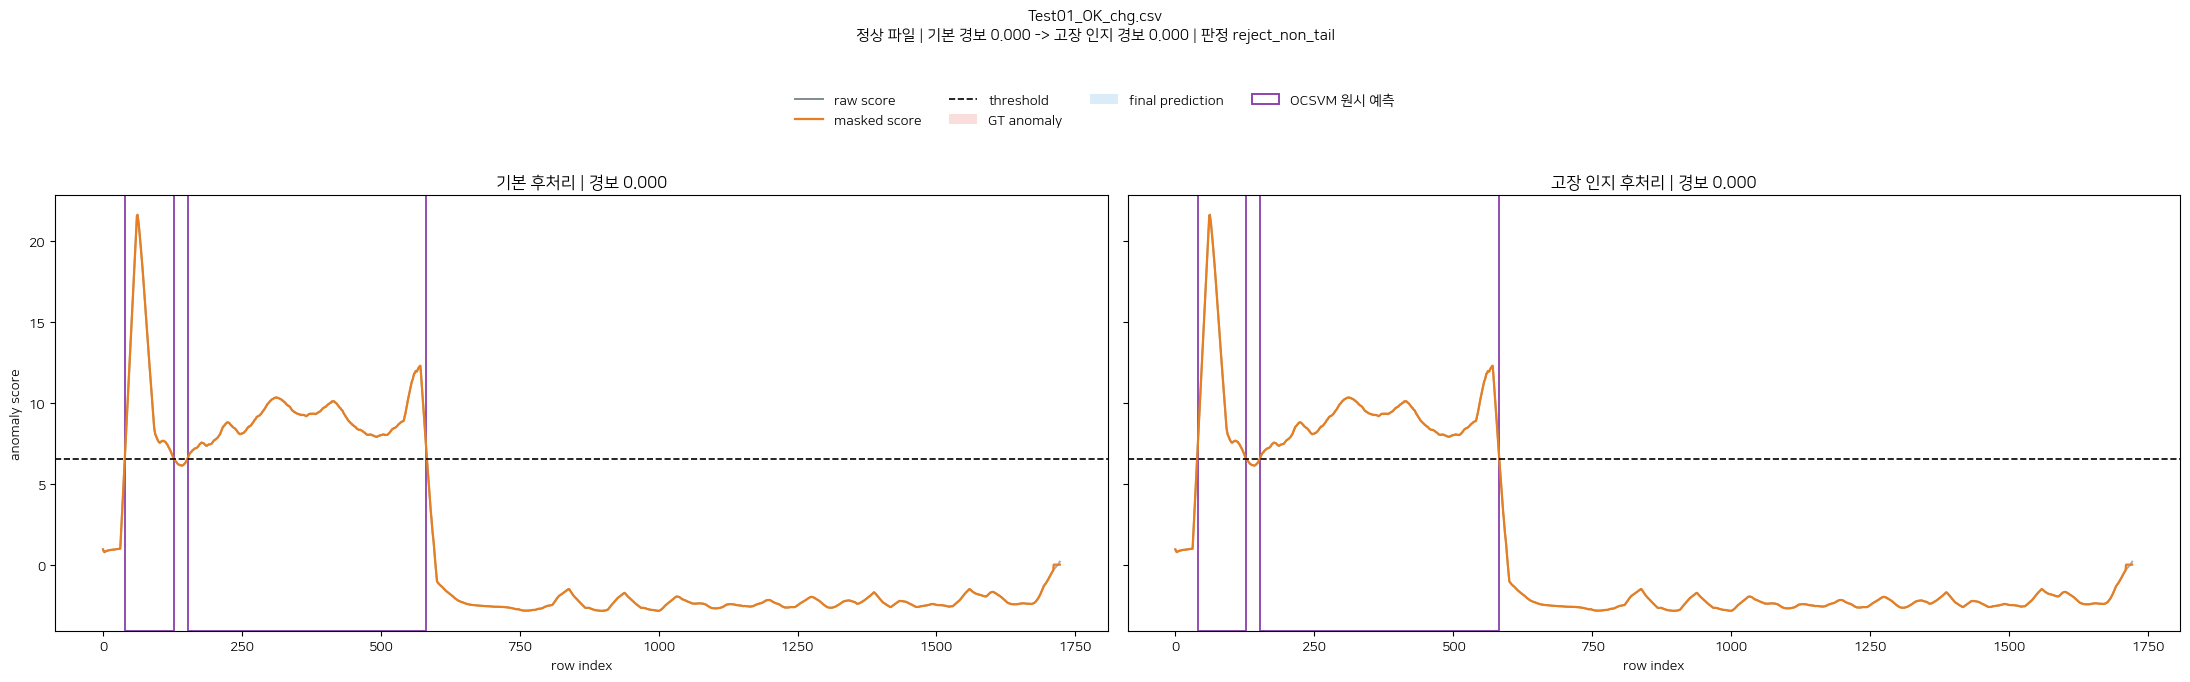

[Test02_OK_dchg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


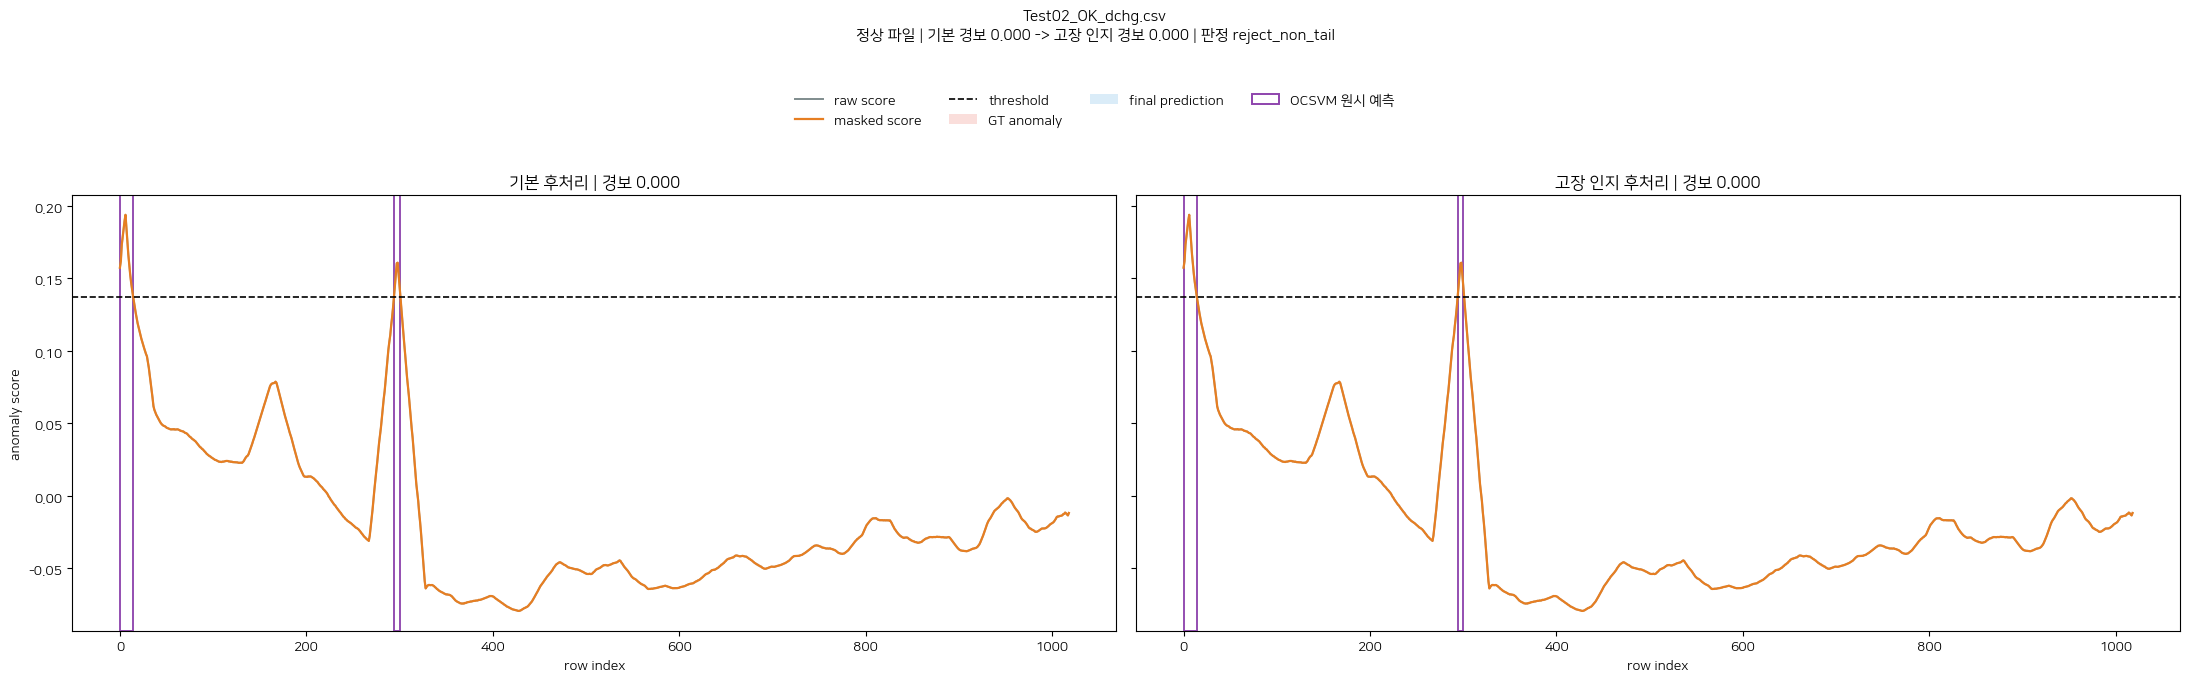

[Test03_OK_chg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


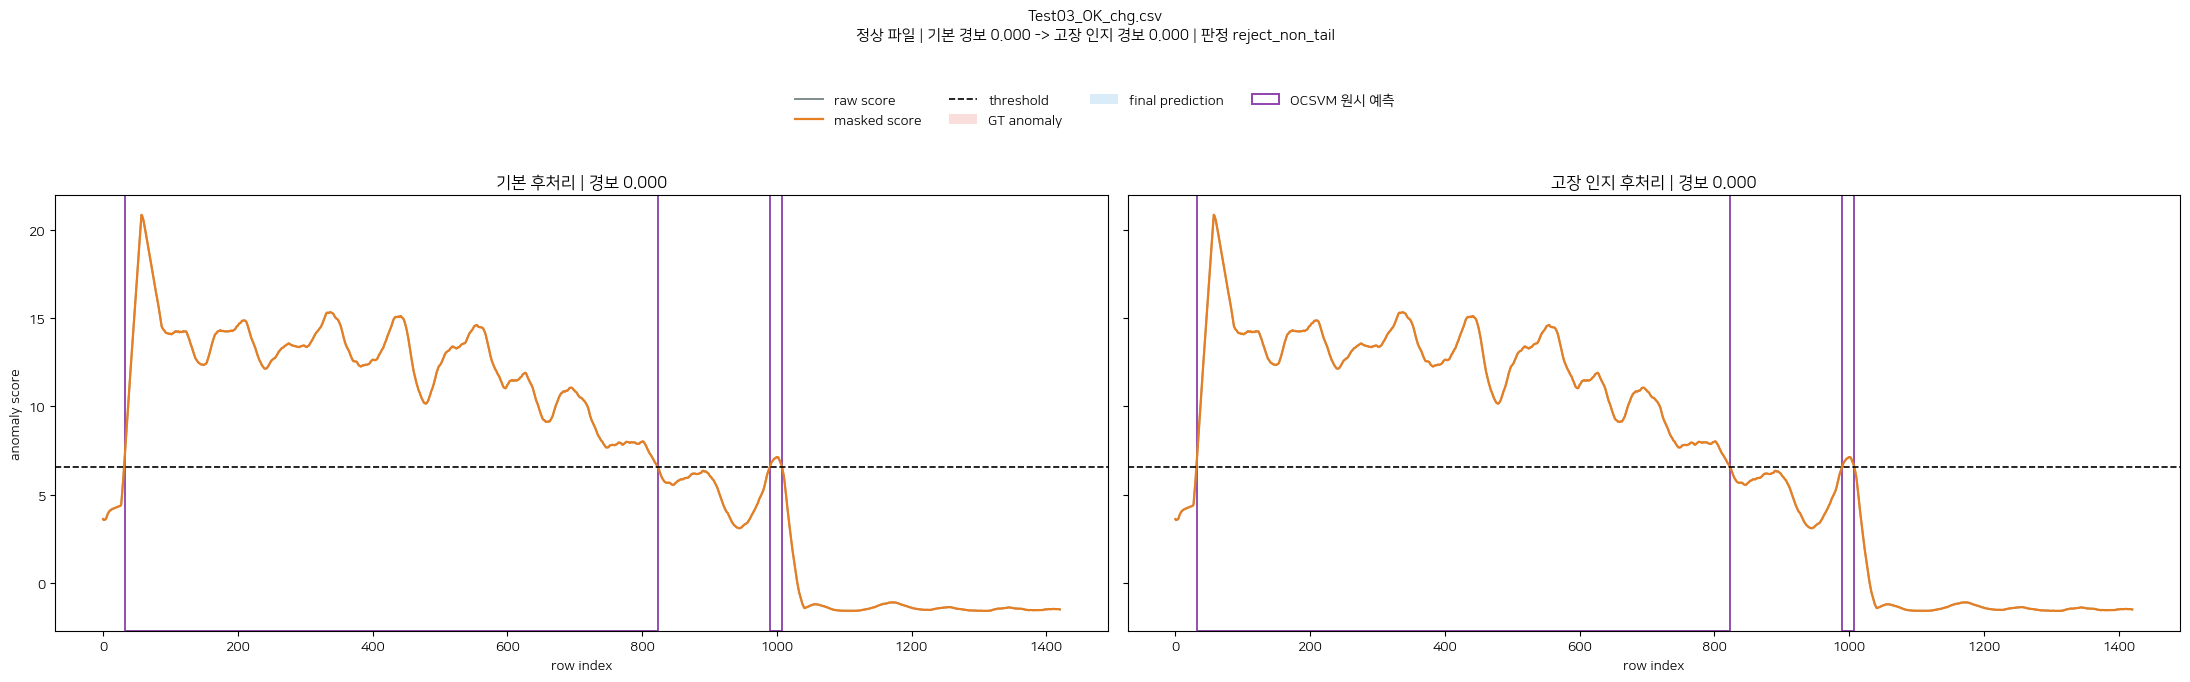

[Test04_OK_dchg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


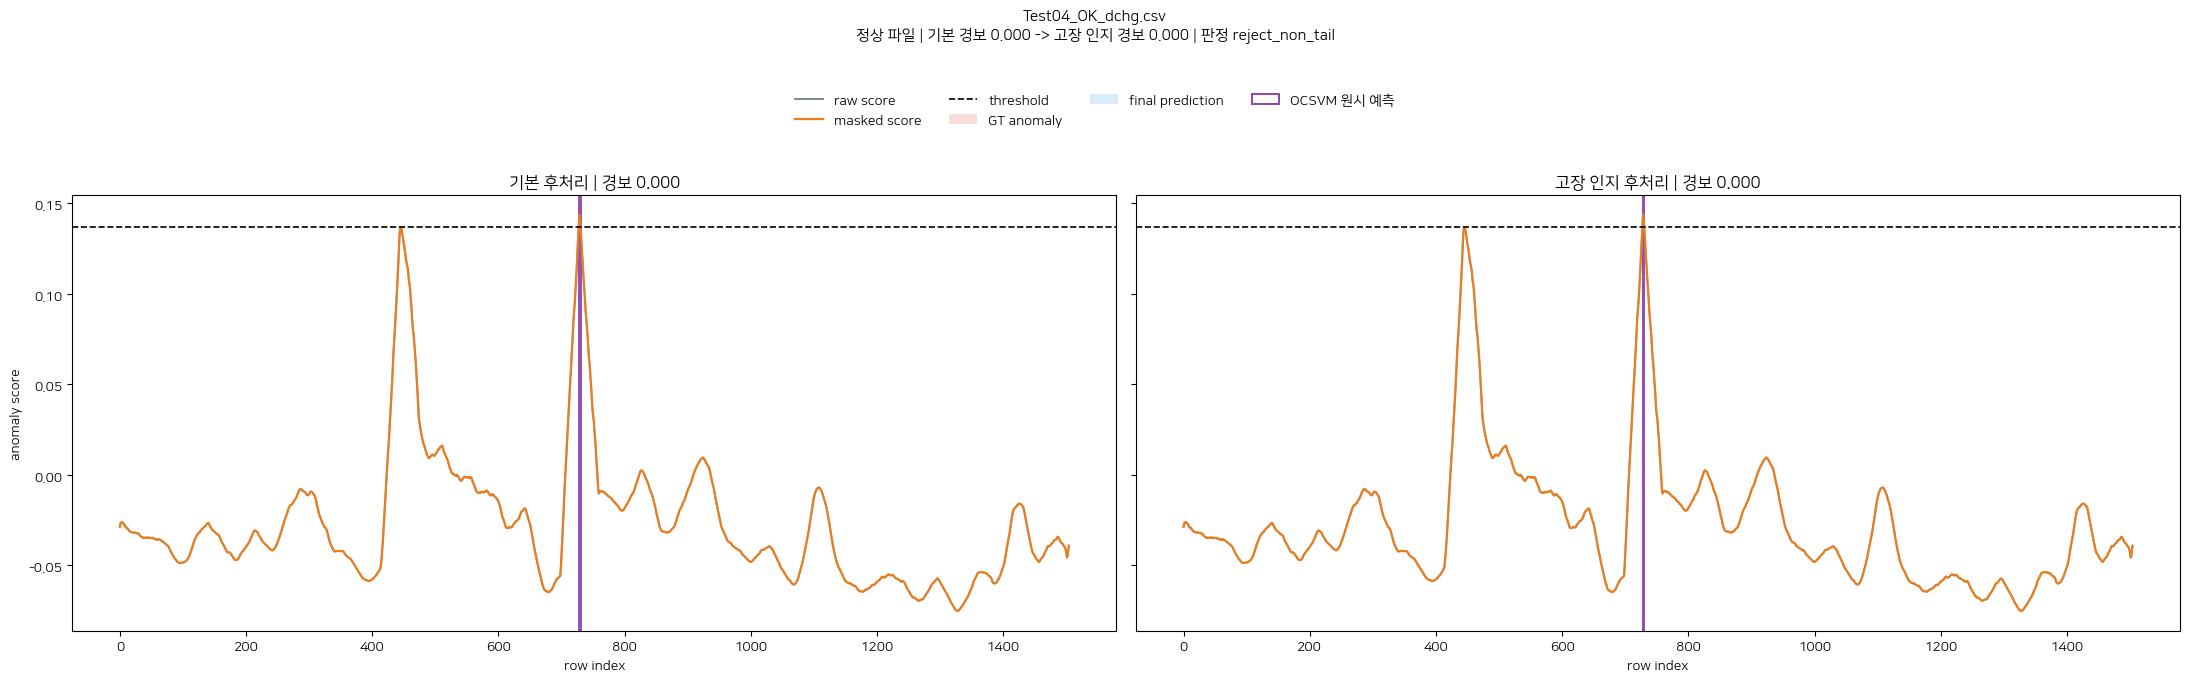

[Test05_NG_chg.csv] 실제 이상 0.849 | 기본 F1 0.562 -> 고장 인지 F1 0.476 | 판정 fault_support_component_merge | 고장유형 센싱와이어불량


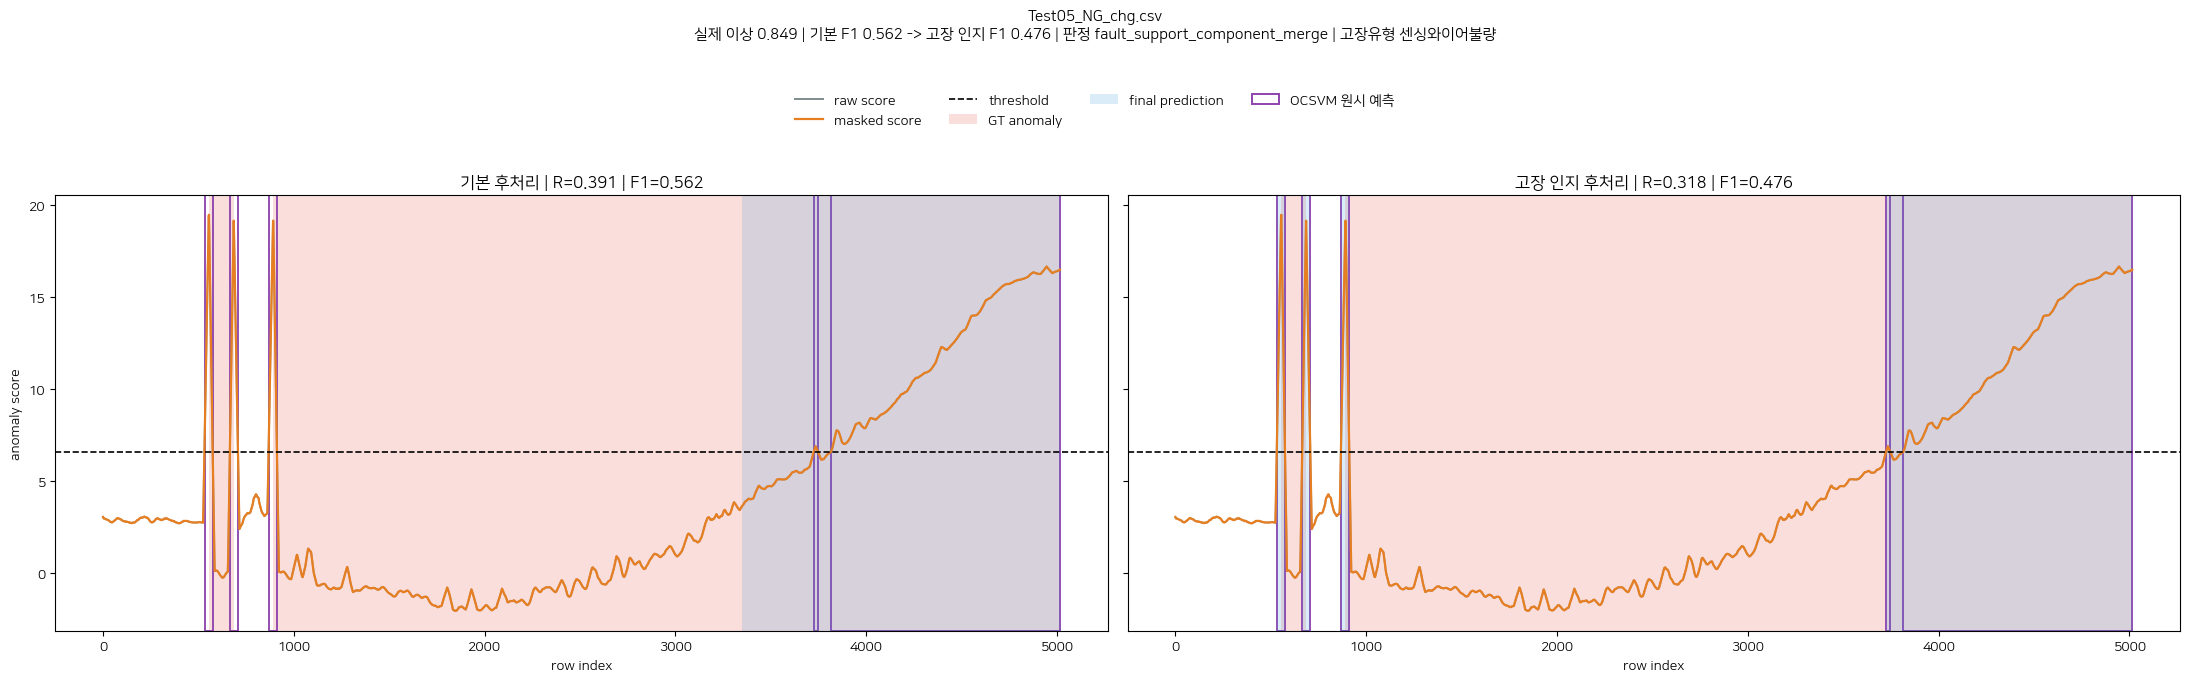

[Test06_NG_chg.csv] 실제 이상 1.000 | 기본 F1 1.000 -> 고장 인지 F1 1.000 | 판정 generalized_bridged | 고장유형 센싱와이어불량


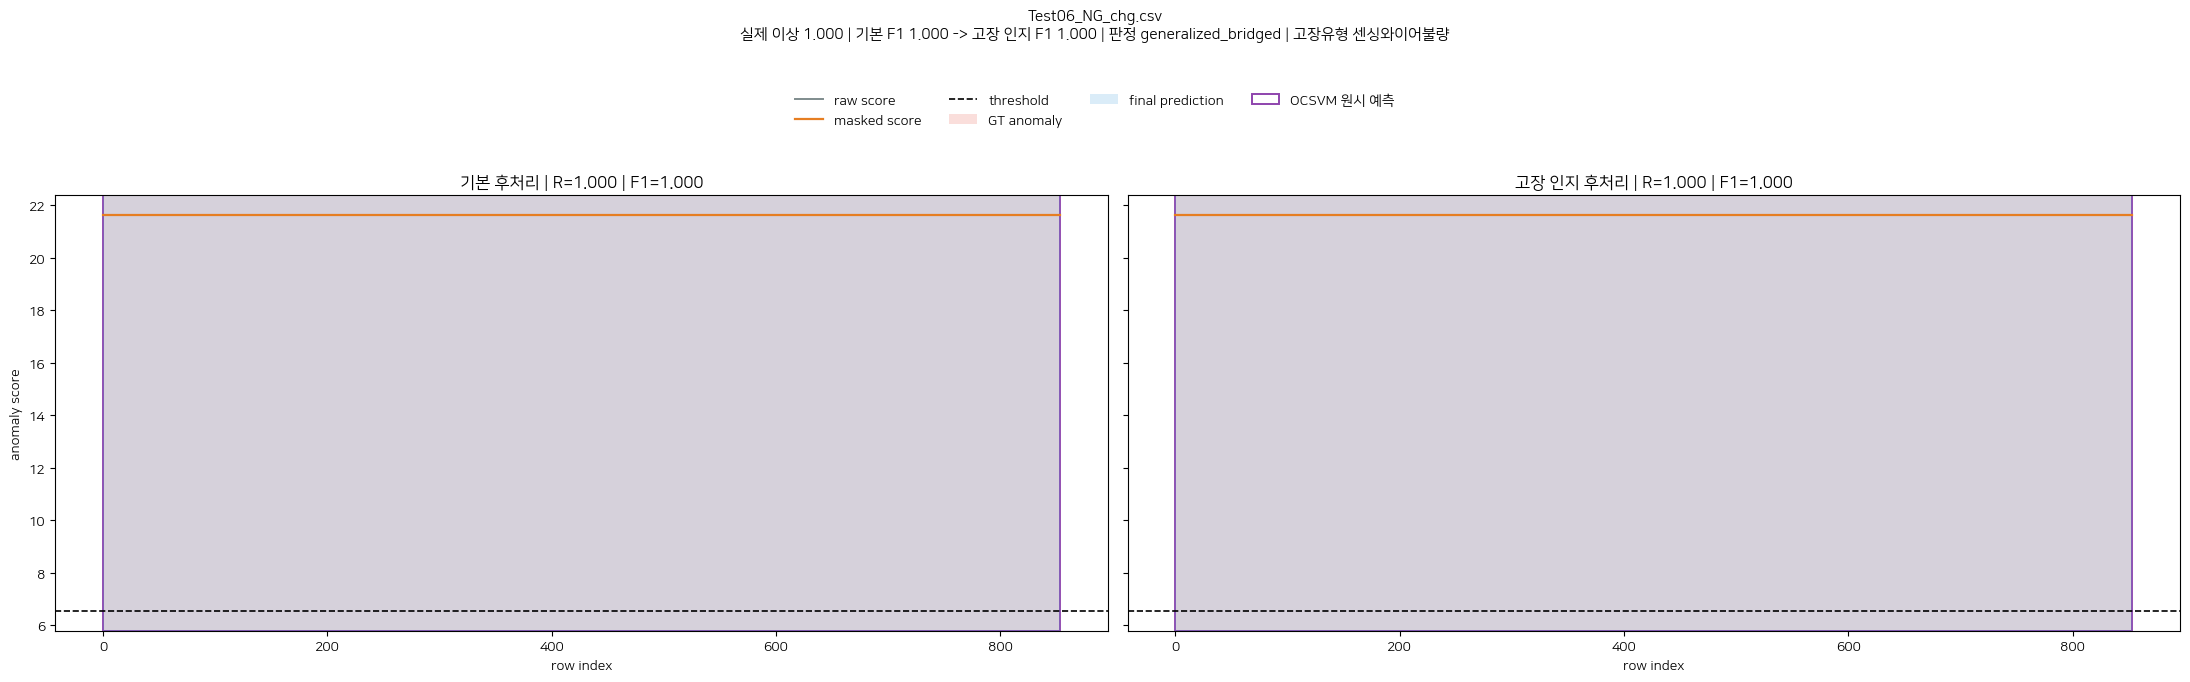

[Test07_NG_dchg.csv] 실제 이상 0.049 | 기본 F1 0.736 -> 고장 인지 F1 0.927 | 판정 fault_support_tail_backpad | 고장유형 센싱와이어불량


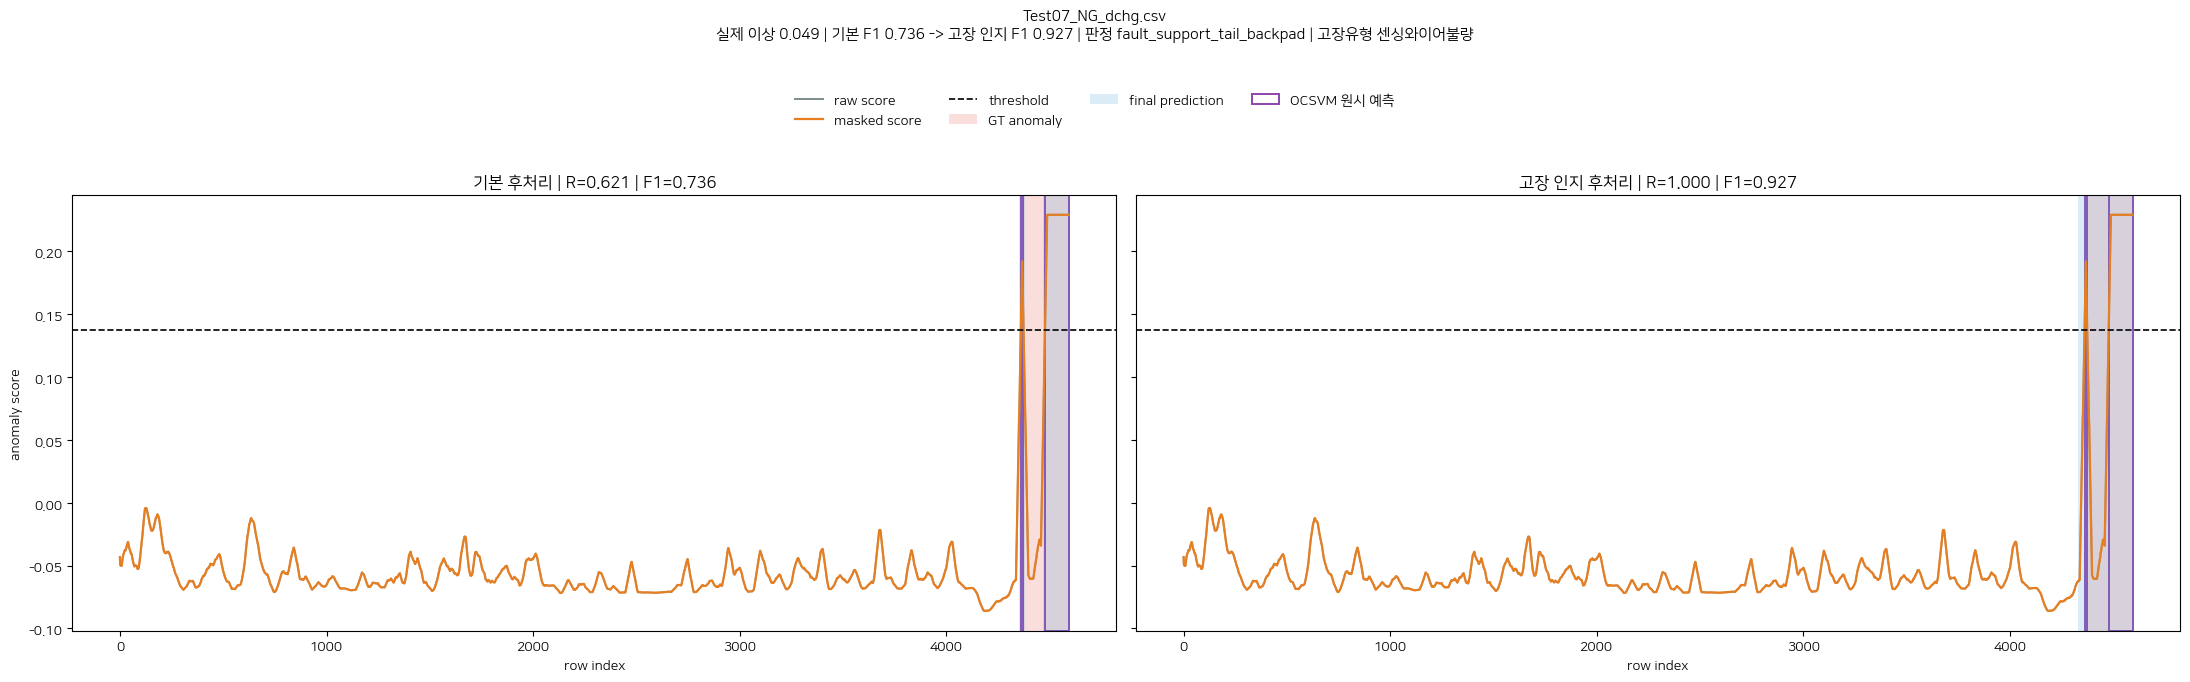

[Test08_NG_chg.csv] 실제 이상 1.000 | 기본 F1 1.000 -> 고장 인지 F1 1.000 | 판정 generalized_bridged | 고장유형 센서불량


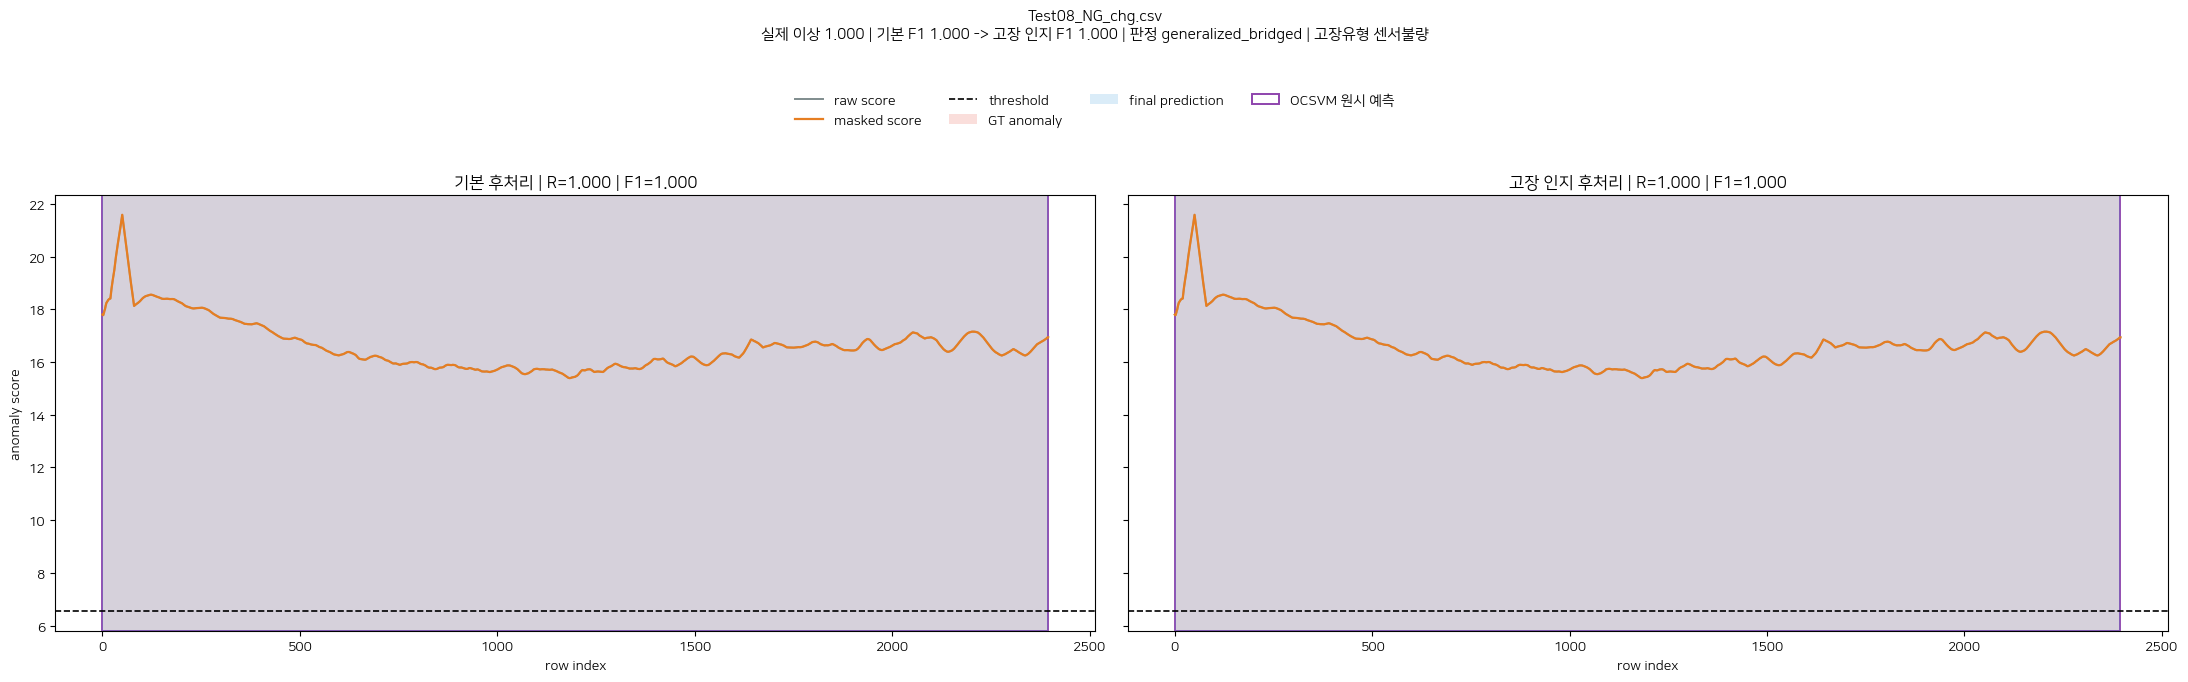

[Test09_NG_dchg.csv] 실제 이상 1.000 | 기본 F1 1.000 -> 고장 인지 F1 1.000 | 판정 generalized_bridged | 고장유형 센서불량


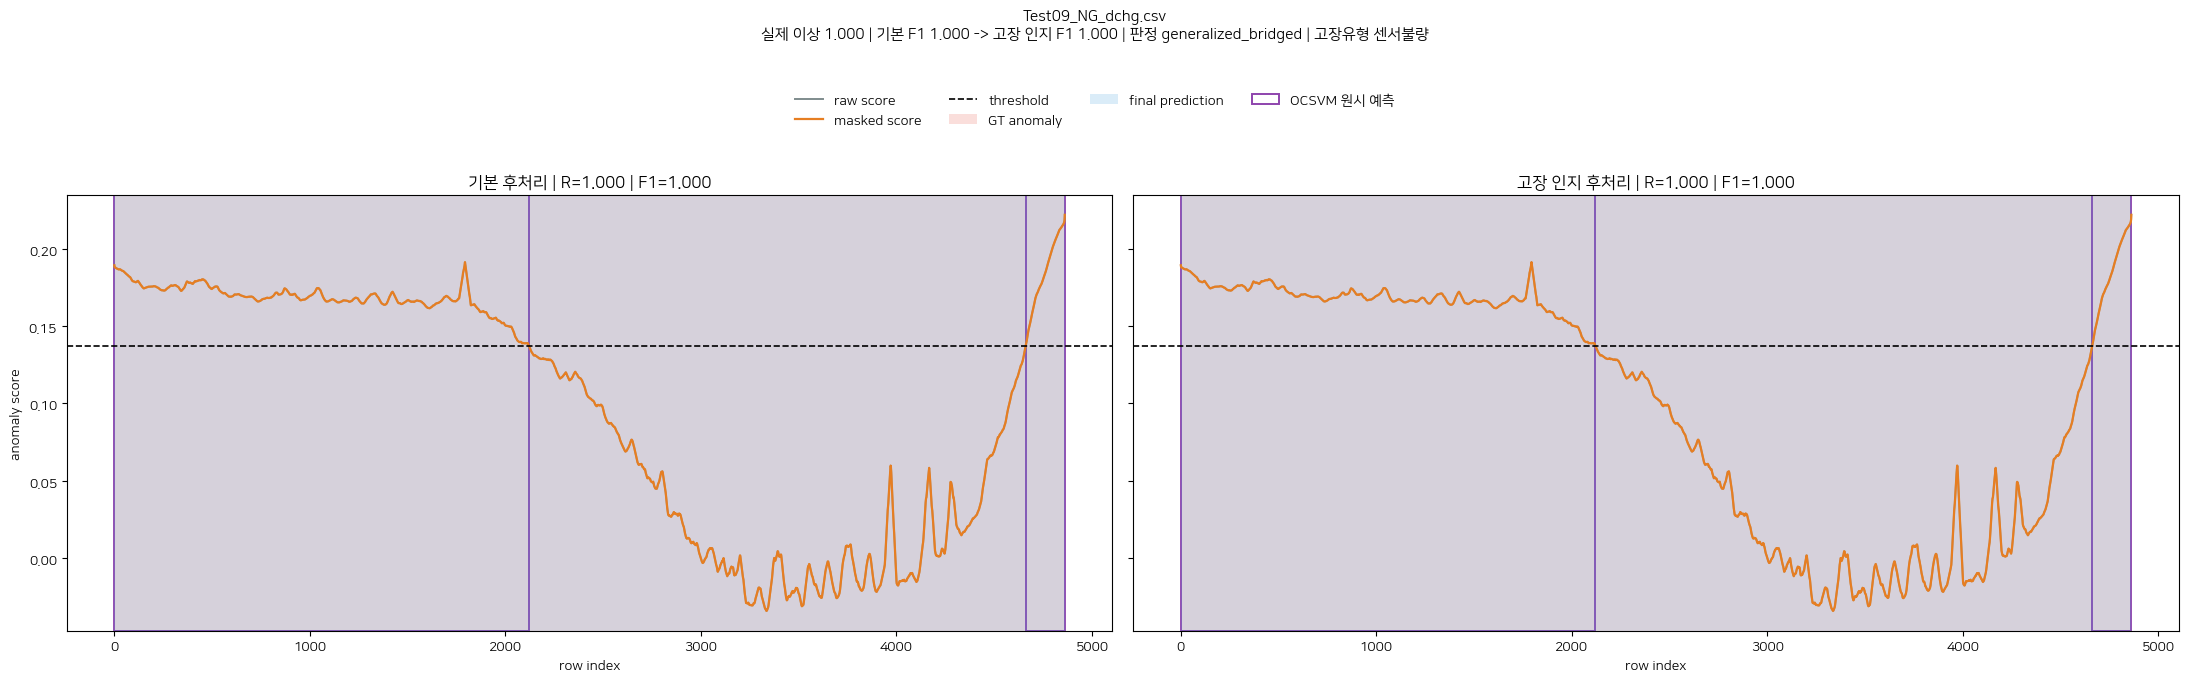

In [28]:
general_detail_map = {row['test_name']: row['detail'] for _, row in train_general_results_df.iterrows()}
fault_detail_map = {row['test_name']: row['detail'] for _, row in train_fault_results_df.iterrows()}

for test_name in TEST_FILES:
    general_row = train_general_results_df.loc[train_general_results_df['test_name'] == test_name].iloc[0]
    fault_row = train_fault_results_df.loc[train_fault_results_df['test_name'] == test_name].iloc[0]
    inferred_fault_name = (
        FAULT_NAME.get(fault_row['top_fault_name'], fault_row['top_fault_name'])
        if fault_row['accept_postfilter'] and float(fault_row['final_pred_ratio']) > 0.0
        else '-'
    )
    if float(fault_row['gt_ratio']) == 0.0:
        summary_text = (
            f"정상 파일 | "
            f"기본 경보 {general_row['final_pred_ratio']:.3f} -> 고장 인지 경보 {fault_row['final_pred_ratio']:.3f} | "
            f"판정 {fault_row['accept_reason']}"
        )
        left_title = f"기본 후처리 | 경보 {general_row['final_pred_ratio']:.3f}"
        right_title = f"고장 인지 후처리 | 경보 {fault_row['final_pred_ratio']:.3f}"
    else:
        summary_text = (
            f"실제 이상 {fault_row['gt_ratio']:.3f} | "
            f"기본 F1 {general_row['final_f1']:.3f} -> 고장 인지 F1 {fault_row['final_f1']:.3f} | "
            f"판정 {fault_row['accept_reason']} | "
            f"고장유형 {inferred_fault_name}"
        )
        left_title = f"기본 후처리 | R={general_row['final_recall']:.3f} | F1={general_row['final_f1']:.3f}"
        right_title = f"고장 인지 후처리 | R={fault_row['final_recall']:.3f} | F1={fault_row['final_f1']:.3f}"
    print(f"[{test_name}] {summary_text}")

    plot_detail_pair(
        general_detail_map[test_name],
        fault_detail_map[test_name],
        left_title=left_title,
        right_title=right_title,
        suptitle=test_name,
        summary_text=summary_text,
    )